# 🚗 Proyecto Integrador — Big Data & Machine Learning
## Especializaciones Implícitas de Vendedores y Predicción de Ventas de Alto Valor

| | |
|---|---|
| **Materia** | Prácticas y Herramientas de Big Data / Machine Learning |
| **Integrantes** | Jose Alexander Quishpe Reinoso · Julián Garofalo |
| **Dataset** | Car Sales Data (~2,500,000 registros) |
| **Carrera** | Ingeniería en Sistemas de Información |

---

## Índice

1. [Introducción](#1)
2. [Descripción del Dataset](#2)
3. [Hipótesis y Objetivos](#3)
4. [Análisis Exploratorio de Datos (EDA)](#4)
   - 4.1 [Estructura del Dataset](#41)
   - 4.2 [Calidad de Datos](#42)
   - 4.3 [Valores Faltantes](#43)
   - 4.4 [Outliers](#44)
   - 4.5 [Distribuciones](#45)
5. [Limpieza y Preprocesamiento](#5)
   - 5.1 [Eliminación de Duplicados](#51)
   - 5.2 [Tratamiento de Nulos](#52)
   - 5.3 [Conversión de Tipos](#53)
   - 5.4 [Ingeniería de Características](#54)
6. [Construcción de la Variable Objetivo](#6)
7. [Selección y Justificación de Variables](#7)
8. [División de Entrenamiento y Prueba](#8)
9. [Entrenamiento de Modelos](#9)
10. [Evaluación de Modelos](#10)
11. [Validación Cruzada](#11)
12. [Importancia de Variables](#12)
13. [Validación de Hipótesis](#13)
14. [Conclusiones](#14)


<a id='1'></a>
---
# 1. Introducción

El sector automotriz constituye uno de los mercados más dinámicos y económicamente relevantes a nivel global, caracterizado por transacciones de alto valor, una fuerte dependencia del factor humano en el proceso comercial y una creciente disponibilidad de datos transaccionales digitalizados. Esta combinación lo convierte en un escenario idóneo para la aplicación de técnicas de **Big Data** y **Machine Learning** orientadas a la generación de conocimiento accionable para la toma de decisiones gerenciales.

El presente proyecto integrador aborda un dataset de **aproximadamente 2,500,000 registros transaccionales** de ventas de vehículos, con el propósito de responder una pregunta de negocio concreta: *¿el desempeño de un vendedor —medido a través de su capacidad de concretar ventas de alto valor— constituye un patrón detectable y predecible mediante algoritmos de clasificación supervisada?*

Para responder esta pregunta de forma metodológicamente rigurosa, el proyecto sigue el flujo estándar de un proceso de Ciencia de Datos (similar a metodologías como **CRISP-DM**):

1. **Comprensión del negocio**: definición de la hipótesis y los objetivos (Sección 3).
2. **Comprensión y preparación de los datos**: exploración, auditoría de calidad y limpieza (Secciones 4 y 5).
3. **Modelado**: construcción de la variable objetivo, selección de variables y entrenamiento de tres algoritmos de complejidad creciente (Secciones 6 a 9).
4. **Evaluación**: comparación de métricas, validación cruzada y análisis de importancia de variables (Secciones 10 a 12).
5. **Conclusión**: validación formal de la hipótesis e implicancias para la gestión comercial (Secciones 13 y 14).

Esta estructura garantiza que cada decisión técnica —desde el tratamiento de un valor nulo hasta la elección del umbral de clasificación— esté respaldada por una justificación explícita, cumpliendo con los estándares esperados en un proyecto final de carácter universitario.


<a id='2'></a>
---
# 2. Descripción del Dataset

## 2.1. Variables Disponibles

El dataset **Car Sales Data** contiene registros transaccionales individuales de ventas de vehículos realizadas por una concesionaria automotriz. Cada fila representa una transacción única.

| Variable | Tipo | Descripción |
|---|---|---|
| `Date` | Fecha | Fecha exacta de la transacción |
| `Salesperson` | Categórica | Nombre del asesor comercial que gestionó la venta |
| `Customer Name` | Categórica | Nombre del comprador |
| `Car Make` | Categórica | Fabricante del vehículo (Toyota, Honda, Ford, Chevrolet, Nissan) |
| `Car Model` | Categórica | Modelo específico del automóvil |
| `Car Year` | Numérica Discreta | Año de fabricación del vehículo |
| `Sale Price` | Numérica Continua | Precio de venta final en USD |
| `Commission Rate` | Numérica Continua | Porcentaje de comisión asignado a la venta |
| `Commission Earned` | Numérica Continua | Monto total de comisión generado |

## 2.2. Origen y Extracción de los Datos

Se plantea una arquitectura de Big Data donde, en primer lugar, se verifica la conectividad con servicios externos (simulando el consumo de una API RESTful pública como parte del flujo de ingesta) y, a continuación, se realiza la lectura masiva del archivo CSV de ~2.5 millones de registros desde el almacenamiento de Google Colab.


In [26]:
# IMPORTACIONES: Aquí traemos las librerías o herramientas externas que el código necesita.
import pandas as pd # Importa Pandas (con el alias pd), ideal para manipular y analizar datos estructurados.
import numpy as np # Importa NumPy (con el alias np), usado para cálculos matemáticos rápidos y manejo de matrices.
import requests # Importa Requests, la librería principal para hacer peticiones a internet y consumir APIs.
import warnings # Importa Warnings, una herramienta nativa para gestionar los mensajes de advertencia de Python.

# CONFIGURACIÓN GENERAL:
warnings.filterwarnings('ignore') # Le decimos a Python que oculte las advertencias no críticas para mantener limpia la consola.

# ─── SIMULACIÓN DE CONSUMO DE API PÚBLICA ───────────────────────────────────

# DEFINICIÓN DE FUNCIÓN: Usamos "def" para crear una función. Esto encapsula un bloque de código para poder reutilizarlo después sin tener que reescribirlo.
def simular_consumo_api_publica():
    '''
    Simula la verificación de disponibilidad de un endpoint de datos automotrices.
    En entornos de producción, esto conectaría con un servicio web RESTful.
    '''
    
    # VARIABLE: Guardamos en texto la dirección de internet (endpoint) a la que nos vamos a conectar.
    url_mock = 'https://jsonplaceholder.typicode.com/posts/1'  # API pública de prueba
    
    # MANEJO DE ERRORES (TRY - EXCEPT): El bloque "try" intenta ejecutar un código que depende de factores externos (como el internet) y que podría fallar.
    try:
        # PETICIÓN HTTP: Intentamos hacer una consulta GET a la URL. El "timeout=5" significa que si tarda más de 5 segundos en responder, se cancela la espera.
        response = requests.get(url_mock, timeout=5)
        
        # CONDICIONAL (IF - ELSE): Evaluamos la respuesta que nos dio el servidor.
        # El código de estado 200 significa "OK" (todo salió bien en el protocolo HTTP).
        if response.status_code == 200:
            # Si la condición de arriba se cumple (es 200), ejecutamos estas impresiones en pantalla indicando éxito.
            print('[API INFO] Conexión con servicios externos establecida con éxito.')
            print('[API INFO] Estado del servicio:', response.status_code)
        else:
            # Si el código no es 200 (por ejemplo, un error 404 o 500), entramos al "else" y avisamos que usaremos un plan de respaldo.
            print('[API WARNING] No se pudo conectar. Usando respaldo local.')
            
    # CAPTURA DE EXCEPCIONES: Si el bloque "try" falla por completo (ej. estás sin internet y la petición se cae), el programa no se cierra abruptamente, sino que salta a este "except".
    except Exception as e:
        # Atrapamos el error en la variable "e" y lo imprimimos para saber exactamente qué falló, permitiendo que el código siga vivo.
        print(f'[API ERROR] Error de red: {e}. Procediendo con carga local.')

# EJECUCIÓN: Todo lo de arriba fue solo la definición. Esta línea es la que realmente "llama" a la función para que se ejecute y haga su trabajo.
simular_consumo_api_publica()


[API INFO] Conexión con servicios externos establecida con éxito.
[API INFO] Estado del servicio: 200


In [27]:
# ─── CARGA MASIVA DESDE GOOGLE COLAB ───────────────────────────────────────

# VARIABLE: Definimos la ruta exacta donde se encuentra el archivo de datos. 
# Esto guarda la ubicación en memoria para no tener que escribirla completa más adelante.
file_path = '/workspaces/car-sales-bigdata/car_sales_data.csv'

# MANEJO DE ERRORES (TRY - EXCEPT): Abrimos un bloque de prueba.
# Python intentará ejecutar lo que está dentro de "try". Si el archivo no está donde dijimos, no se romperá el programa, sino que saltará directo al "except".
try:
    # LECTURA DE DATOS: Utilizamos la función read_csv de Pandas para abrir el archivo. 
    # Todo ese volumen de datos se carga y organiza dentro de la variable "df" (que significa DataFrame, la tabla principal).
    df = pd.read_csv(file_path)
    
    # IMPRESIONES CON FORMATO (F-STRINGS): Al poner una "f" antes de las comillas, podemos inyectar variables directamente usando llaves {}. 
    # Aquí confirmamos que la carga fue exitosa mostrando la ruta.
    print(f'[ÉXITO] Dataset extraído correctamente desde: {file_path}')
    
    # CONTEO DE FILAS: len(df) cuenta cuántos registros exactos se cargaron.
    # El símbolo ":," es un truco de formato para que el número grande aparezca con comas separadoras de miles, haciéndolo muy fácil de leer.
    print(f'Total de registros cargados en memoria: {len(df):,}')
    
    # SALTO DE LÍNEA: El símbolo "\n" le dice a la consola que haga un "Enter" o salto de línea antes de imprimir, manteniendo todo ordenado.
    print('\nEstructura inicial de las variables:')
    
    # INSPECCIÓN DE TIPOS: df.dtypes revisa todas las columnas de tu tabla y te dice qué tipo de dato hay en cada una (números, texto, fechas, etc.).
    print(df.dtypes)
    
    print('\nPrimeras filas:')
    
    # VISTA PREVIA: display() es una función especial de entornos como Colab que renderiza las tablas bonitas. 
    # df.head() toma únicamente las primeras 5 filas de tus millones de registros para que puedas echarles un vistazo rápido sin congelar la pantalla.
    display(df.head())

# CAPTURA DE ERROR ESPECÍFICO: Si el "try" falla exclusivamente porque el archivo no existe en la ruta, se activa este bloque.
except FileNotFoundError:
    # Mostramos un mensaje claro avisando qué falló y damos la instrucción precisa de cómo solucionarlo subiendo el archivo.
    print(f'[ERROR] Archivo no encontrado en: {file_path}')
    print("Sube el archivo 'car_sales_data.csv' a la sección de archivos de Colab.")


[ÉXITO] Dataset extraído correctamente desde: /workspaces/car-sales-bigdata/car_sales_data.csv
Total de registros cargados en memoria: 2,500,000

Estructura inicial de las variables:
Date                     str
Salesperson              str
Customer Name            str
Car Make                 str
Car Model                str
Car Year               int64
Sale Price             int64
Commission Rate      float64
Commission Earned    float64
dtype: object

Primeras filas:


,Date,Salesperson,Customer Name,Car Make,Car Model,Car Year,Sale Price,Commission Rate,Commission Earned
0,2022-08-01,Monica Moore MD,Mary Butler,Nissan,Altima,2018,15983,0.070495,1126.73
1,2023-03-15,Roberto Rose,Richard Pierce,Nissan,F-150,2016,38474,0.134439,5172.40
2,2023-04-29,Ashley Ramos,Sandra Moore,Ford,Civic,2016,33340,0.114536,3818.63
3,2022-09-04,Patrick Harris,Johnny Scott,Ford,Altima,2013,41937,0.092191,3866.20
4,2022-06-16,Eric Lopez,Vanessa Jones,Honda,Silverado,2022,20256,0.113490,2298.85


<a id='3'></a>
---
# 3. Hipótesis y Objetivos

## 3.1. Pregunta de Investigación

> ¿Es posible determinar, mediante técnicas de clasificación supervisada, si el **vendedor** constituye un factor relevante para predecir si una venta generará ingresos superiores al percentil 75 del precio de mercado?

## 3.2. Hipótesis Central

> **"Existen especializaciones implícitas entre los vendedores que influyen significativamente en la probabilidad de concretar ventas de alto valor dentro de una concesionaria automotriz."**

## 3.3. Fundamento Conceptual

La hipótesis se sustenta en el concepto de **especialización comercial implícita**: la tendencia —no declarada formalmente— de ciertos asesores de ventas a orientar su actividad hacia segmentos de mayor valor económico, independientemente de las políticas institucionales de asignación de clientes. Esta especialización puede emerger de factores como la experiencia acumulada, la red de contactos, la capacidad de negociación o las preferencias personales por determinadas marcas.

Si esta especialización existe de forma estadísticamente significativa, la variable `Salesperson` debería constituir un predictor relevante dentro de un modelo de clasificación supervisada.

## 3.4. Justificación de la Investigación

- El sector automotriz se caracteriza por transacciones de **alta variabilidad económica** y por la presencia de un factor humano determinante en el proceso de venta.
- Identificar patrones de especialización ocultos en 2.5 M de registros representa un aporte de alto valor para la toma de decisiones gerenciales.
- La aplicación de ML sobre Big Data permite demostrar competencias avanzadas en ingeniería de características y validación estadística de hipótesis empresariales.

## 3.5. Objetivo General

Determinar si la variable `Salesperson` constituye un factor estadísticamente significativo para predecir la probabilidad de concretar una venta de alto valor (≥ percentil 75 del precio de venta), mediante la aplicación y comparación de tres modelos de clasificación supervisada.

## 3.6. Objetivos Específicos

1. Realizar un análisis exploratorio exhaustivo del dataset de 2,500,000 registros, evaluando su estructura, calidad y distribuciones.
2. Detectar y tratar metodológicamente los valores atípicos, nulos e inconsistencias presentes en los datos.
3. Construir la variable binaria objetivo `High_Value_Sale` a partir del umbral del percentil 75.
4. Seleccionar y justificar formalmente las variables predictoras, evitando *data leakage*.
5. Entrenar tres modelos de clasificación: Regresión Logística, Random Forest y XGBoost.
6. Validar la robustez de los modelos mediante validación cruzada.
7. Analizar la importancia de variables del Random Forest para cuantificar el peso de `Salesperson`.
8. Validar o refutar la hipótesis con base en evidencia cuantitativa.


<a id='4'></a>
---
# 4. Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos (EDA) constituye una etapa metodológicamente indispensable previa a cualquier proceso de modelado. Su propósito es comprender la estructura, calidad y comportamiento estadístico del dataset **antes** de tomar decisiones de limpieza o de ingeniería de características, evitando así transformaciones arbitrarias no respaldadas por evidencia.

En esta sección se analiza el dataset en su estado **original** (sin modificar). Las acciones de limpieza correspondientes a los hallazgos de esta sección se ejecutan formalmente en la Sección 5.


<a id='41'></a>
## 4.1. Estructura del Dataset

Se examinan las dimensiones, los tipos de dato asignados por pandas y las estadísticas descriptivas básicas, tanto para variables numéricas como categóricas. Este primer acercamiento permite detectar de forma temprana inconsistencias de tipo (por ejemplo, una variable numérica leída como texto) y dimensionar la magnitud computacional del problema.


In [28]:
# CONDICIÓN DE EXISTENCIA: Verificamos si la variable 'df' (el DataFrame) existe en la memoria local actual usando la función "locals()".
# Esto es una red de seguridad: evita que el código intente analizar algo que aún no ha sido cargado, previniendo errores graves.
if 'df' in locals():
    # FORMATO VISUAL: Multiplicamos el símbolo '=' por 70 para imprimir una línea divisoria. Esto ayuda a estructurar visualmente la salida en consola.
    print('='*70)
    print('  4.1 ESTRUCTURA DEL DATASET')
    print('='*70)

    # ─── DIMENSIONES ─────────────────────────────────────────────────────
    # EXTRACCIÓN DE TAMAÑO: df.shape es una propiedad que devuelve una tupla (filas, columnas).
    # shape[0] extrae la cantidad de filas (con ":," para mostrar separadores de miles) y shape[1] extrae la cantidad de columnas.
    print(f'\nDimensiones del dataset: {df.shape[0]:,} filas  x  {df.shape[1]} columnas')

    # ─── TIPOS DE DATOS ──────────────────────────────────────────────────
    print('\n--- Tipos de datos asignados por pandas ---')
    # INSPECCIÓN DE COLUMNAS: df.dtypes imprime una lista rápida de cada columna y el tipo de dato que contiene (enteros, decimales, texto, etc.).
    print(df.dtypes)

    # ─── INFORMACIÓN GENERAL (memoria, nulos por columna) ───────────────
    print('\n--- Información general del DataFrame ---')
    # REPORTE TÉCNICO: df.info() genera un resumen que incluye el recuento de valores no nulos.
    # El parámetro "memory_usage='deep'" obliga a Pandas a inspeccionar a fondo los datos para darte el consumo exacto y real de memoria RAM.
    df.info(memory_usage='deep')

    # ─── ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS ─────────────────
    print('\n--- Estadísticas descriptivas: variables numéricas ---')
    # MATEMÁTICAS RÁPIDAS: df.describe() calcula automáticamente el conteo, promedio, desviación estándar, mínimos, máximos y percentiles.
    # "include=[np.number]" asegura que solo se aplique a las columnas con valores numéricos.
    # El ".T" al final significa "Transponer": rota la tabla para convertir filas en columnas, haciéndola mucho más fácil de leer en la pantalla.
    display(df.describe(include=[np.number]).T)

    # ─── ESTADÍSTICAS DESCRIPTIVAS — VARIABLES CATEGÓRICAS ───────────────
    print('\n--- Estadísticas descriptivas: variables categóricas ---')
    # ANÁLISIS DE TEXTO: Al usar "include=['object']", le decimos a Pandas que analice solo las columnas de texto (categorías).
    # En lugar de promedios matemáticos, esto calcula el total, cuántos valores únicos hay, cuál es el valor más frecuente (la moda) y su frecuencia.
    display(df.describe(include=['object']).T)

# BLOQUE ALTERNATIVO (ELSE): Si la comprobación inicial falla ('df' no existe en memoria), el flujo del programa salta directamente aquí.
else:
    # MENSAJE DE CONTROL: Imprimimos una instrucción clara para que sepas qué salió mal y cómo corregirlo sin que el sistema colapse.
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')


  4.1 ESTRUCTURA DEL DATASET

Dimensiones del dataset: 2,500,000 filas  x  9 columnas

--- Tipos de datos asignados por pandas ---
Date                     str
Salesperson              str
Customer Name            str
Car Make                 str
Car Model                str
Car Year               int64
Sale Price             int64
Commission Rate      float64
Commission Earned    float64
dtype: object

--- Información general del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Date               str    
 1   Salesperson        str    
 2   Customer Name      str    
 3   Car Make           str    
 4   Car Model          str    
 5   Car Year           int64  
 6   Sale Price         int64  
 7   Commission Rate    float64
 8   Commission Earned  float64
dtypes: float64(2), int64(2), str(5)
memory usage: 777.1 MB

--- Estadísticas descriptivas: variab

,count,mean,std,min,25%,50%,75%,max
Car Year,2500000.0,2015.996222,3.739132,2010.00,2013.000000,2016.000000,2019.000000,2022.00
Sale Price,2500000.0,30012.178742,11545.136842,10000.00,20019.000000,30006.000000,40022.000000,50000.00
Commission Rate,2500000.0,0.099988,0.028872,0.05,0.074964,0.100006,0.125006,0.15
Commission Earned,2500000.0,3001.005337,1481.467434,501.34,1821.710000,2741.910000,3978.142500,7494.53



--- Estadísticas descriptivas: variables categóricas ---


,count,unique,top,freq
Date,2500000,366,2022-12-24,7144
Salesperson,2500000,518657,Michael Smith,1229
Customer Name,2500000,518251,Michael Smith,1167
Car Make,2500000,5,Honda,500687
Car Model,2500000,5,Silverado,500842


**Interpretación.** El dataset confirma una escala cercana a los 2.5 millones de registros, lo que justifica las decisiones de optimización computacional adoptadas a lo largo del proyecto (uso de tipos de dato eficientes, muestreo para visualizaciones y validación cruzada sobre submuestras representativas en la Sección 11). La salida de `describe()` sobre las variables categóricas permite además identificar la **cardinalidad** de `Salesperson`, `Car Make` y `Car Model` — un factor relevante para decidir la técnica de codificación en la Sección 7.4.


<a id='42'></a>
## 4.2. Calidad de Datos

Un dataset de origen transaccional —especialmente a escala de millones de registros— suele contener inconsistencias propias de procesos de captura automatizados: duplicados exactos, valores fuera de rango físicamente imposibles, o fechas mal formateadas. Esta subsección audita la calidad del dato **sin modificarlo**, dejando la corrección formal para la Sección 5.


In [29]:
# CONDICIÓN DE EXISTENCIA: Al igual que en la sección anterior, confirmamos que el DataFrame 'df' esté cargado en la memoria local para evitar errores de ejecución.
if 'df' in locals():
    # FORMATO VISUAL: Imprimimos encabezados para que la salida en consola sea fácil de leer y separe las secciones de la auditoría.
    print('='*70)
    print('  4.2 AUDITORÍA DE CALIDAD DE DATOS')
    print('='*70)

    # ─── REGISTROS DUPLICADOS ────────────────────────────────────────────
    # BÚSQUEDA DE DUPLICADOS: df.duplicated() revisa fila por fila si existe otra exactamente igual. 
    # El ".sum()" suma todos los resultados verdaderos para darnos el número total de copias exactas.
    n_duplicados = df.duplicated().sum()
    
    # IMPRESIÓN CON CÁLCULO: Mostramos el total de duplicados y, dentro del f-string, calculamos qué porcentaje representan del total de datos (n_duplicados dividido para len(df)).
    print(f'\n[1] Registros completamente duplicados: {n_duplicados:,} '
          f'({n_duplicados/len(df)*100:.3f}% del total)')

    # ─── VALIDACIÓN DE RANGOS — Car Year ─────────────────────────────────
    # TIEMPO ACTUAL: pd.Timestamp.now().year obtiene el año en curso exacto desde el sistema.
    anio_actual = pd.Timestamp.now().year
    
    # FILTRO CONDICIONAL MULTIPLE: Buscamos filas donde el año del auto sea menor a 1900 (el símbolo "|" significa "O") mayor al año actual. 
    # Guardamos esos registros anómalos en "anio_invalido".
    anio_invalido = df[(df['Car Year'] < 1900) | (df['Car Year'] > anio_actual)]
    
    # Contamos cuántos errores encontramos usando "len()" y los imprimimos.
    print(f'\n[2] Registros con "Car Year" fuera de rango plausible (1900-{anio_actual}): '
          f'{len(anio_invalido):,}')

    # ─── VALIDACIÓN DE RANGOS — Sale Price ───────────────────────────────
    # CONVERSIÓN SEGURA: pd.to_numeric intenta forzar la columna a números. El "errors='coerce'" hace que si encuentra un texto que no puede convertir, lo convierta en "NaN" (nulo) en lugar de romper el programa.
    # Luego, filtramos aquellos precios que sean menores o iguales a cero.
    precio_invalido = df[pd.to_numeric(df['Sale Price'], errors='coerce') <= 0]
    print(f'[3] Registros con "Sale Price" <= 0 (imposible comercialmente): '
          f'{len(precio_invalido):,}')

    # ─── VALIDACIÓN DE RANGOS — Commission Rate ──────────────────────────
    # CONDICIÓN COMPUESTA: Similar al anterior, convertimos la tasa de comisión a número de forma segura.
    # Comprobamos si la comisión es menor a 0 o (símbolo "|") mayor a 1 (lo que equivaldría a más del 100%).
    comision_invalida = df[(pd.to_numeric(df['Commission Rate'], errors='coerce') < 0) |
                            (pd.to_numeric(df['Commission Rate'], errors='coerce') > 1)]
    print(f'[4] Registros con "Commission Rate" fuera del rango [0, 1]: '
          f'{len(comision_invalida):,}')

    # ─── VERIFICACIÓN DE FECHAS ───────────────────────────────────────────
    # PARSEO DE FECHAS: pd.to_datetime convierte textos a formato de fecha real de Pandas. Usamos "coerce" para volver nulas las fechas que sean puro texto basura.
    fechas_parseadas = pd.to_datetime(df['Date'], errors='coerce')
    
    # CONTEO DE NULOS: isna() identifica cuáles valores quedaron como nulos (fechas inválidas) y sum() los cuenta.
    fechas_invalidas = fechas_parseadas.isna().sum()
    
    # VERIFICACIÓN FUTURA: Comparamos las fechas válidas contra la fecha y hora de hoy para detectar ventas registradas en el futuro.
    fechas_futuras = (fechas_parseadas > pd.Timestamp.now()).sum()
    
    print(f'[5] Fechas no interpretables (formato inválido): {fechas_invalidas:,}')
    print(f'[6] Fechas con valor futuro respecto a hoy: {fechas_futuras:,}')

    # ─── CONSISTENCIA DE TIPOS ────────────────────────────────────────────
    print('\n[7] Tipos de dato actuales vs. tipo esperado:')
    
    # DICCIONARIO: Creamos una estructura de pares clave-valor (nombre de columna : tipo ideal) para mapear lo que deberíamos tener en los datos limpios.
    tipos_esperados = {
        'Date': 'fecha', 'Sale Price': 'numérico', 'Commission Rate': 'numérico',
        'Commission Earned': 'numérico', 'Car Year': 'numérico'
    }
    
    # BUCLE FOR: Recorremos el diccionario creado arriba. En cada vuelta, "col" toma el nombre de la columna y "esperado" toma el tipo ideal.
    for col, esperado in tipos_esperados.items():
        # IMPRESIÓN FORMATEADA: Comparamos el tipo real que tiene el DataFrame en ese momento (str(df[col].dtype)) frente a lo que dictamos en el diccionario.
        # Los símbolos "<20" y "<12" en el f-string alinean los textos a la izquierda con espacios para que se vea como una tabla limpia en consola.
        print(f'    {col:<20} dtype actual: {str(df[col].dtype):<12}  →  esperado: {esperado}')

# BLOQUE ALTERNATIVO (ELSE): Si 'df' no existe en memoria, el programa ignora todo el código de arriba y viene directo aquí.
else:
    # Mostramos el mensaje de advertencia indicando que falta el paso previo.
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')


  4.2 AUDITORÍA DE CALIDAD DE DATOS



[1] Registros completamente duplicados: 0 (0.000% del total)

[2] Registros con "Car Year" fuera de rango plausible (1900-2026): 0
[3] Registros con "Sale Price" <= 0 (imposible comercialmente): 0
[4] Registros con "Commission Rate" fuera del rango [0, 1]: 0
[5] Fechas no interpretables (formato inválido): 0
[6] Fechas con valor futuro respecto a hoy: 0

[7] Tipos de dato actuales vs. tipo esperado:
    Date                 dtype actual: str           →  esperado: fecha
    Sale Price           dtype actual: int64         →  esperado: numérico
    Commission Rate      dtype actual: float64       →  esperado: numérico
    Commission Earned    dtype actual: float64       →  esperado: numérico
    Car Year             dtype actual: int64         →  esperado: numérico


**Interpretación y decisión metodológica.** Los resultados anteriores determinan tres acciones de limpieza que se ejecutarán formalmente en la Sección 5:

1. **Duplicados exactos** → se eliminan en su totalidad (Sección 5.1), dado que no aportan información adicional y sesgarían el entrenamiento al sobre-representar ciertas combinaciones de variables.
2. **Registros con valores fuera de rango** (`Car Year`, `Sale Price`, `Commission Rate`) → se tratan como errores de captura y se excluyen del conjunto de modelado (Sección 5.3), ya que su inclusión introduciría ruido no representativo del fenómeno de negocio bajo estudio.
3. **Fechas no interpretables** → se convierten a `NaT` mediante `errors='coerce'` y se gestionan junto con el resto de valores nulos (Sección 5.2), preservando la integridad de las demás columnas del mismo registro cuando es posible.


<a id='43'></a>
## 4.3. Valores Faltantes

La presencia de valores nulos (`NaN`) puede introducir sesgos severos si no se gestiona adecuadamente: los algoritmos de scikit-learn y XGBoost utilizados en este proyecto no aceptan valores faltantes en las variables predictoras, por lo que su tratamiento es un requisito técnico ineludible, además de una buena práctica metodológica.


  4.3 ANÁLISIS DE VALORES FALTANTES

Resumen de valores faltantes por columna:


,Conteo de Nulos,Porcentaje (%)
Date,0,0.0
Salesperson,0,0.0
Customer Name,0,0.0
Car Make,0,0.0
Car Model,0,0.0
Car Year,0,0.0
Sale Price,0,0.0
Commission Rate,0,0.0
Commission Earned,0,0.0


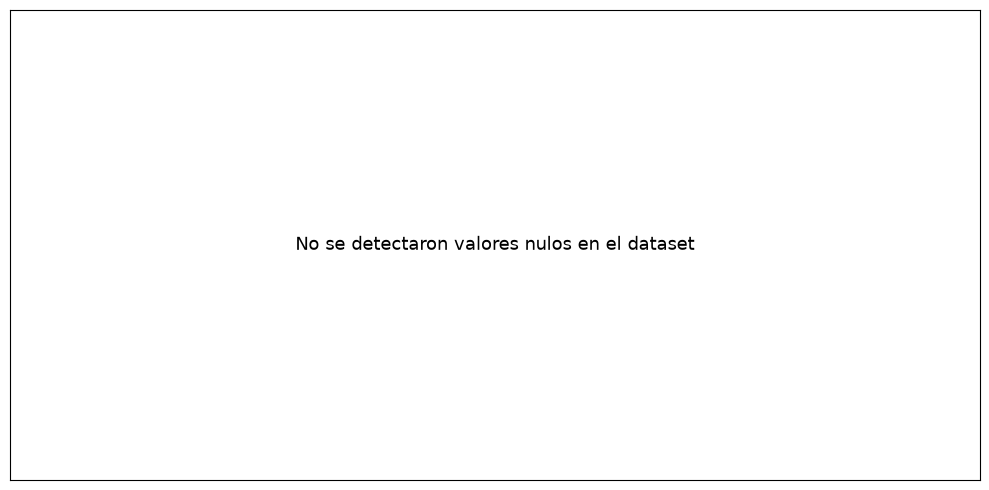

In [30]:
# CONDICIÓN DE EXISTENCIA: Verificamos una vez más que el DataFrame 'df' esté en memoria antes de intentar cualquier análisis.
if 'df' in locals():
    # FORMATO VISUAL: Imprimimos el encabezado de esta nueva sección.
    print('='*70)
    print('  4.3 ANÁLISIS DE VALORES FALTANTES')
    print('='*70)

    # CÁLCULO DE NULOS: df.isnull() detecta los espacios vacíos (NaN) y .sum() los suma por cada columna.
    nulos_conteo = df.isnull().sum()
    
    # CÁLCULO DE PORCENTAJE: Dividimos el conteo de nulos entre el total de filas (len(df)), multiplicamos por 100 y redondeamos a 3 decimales para tener un porcentaje preciso.
    nulos_pct    = (nulos_conteo / len(df) * 100).round(3)

    # CREACIÓN DE TABLA RESUMEN: Usamos pd.DataFrame para crear una nueva tabla pequeña a partir de los cálculos anteriores.
    # El sort_values ordena esta tabla de mayor a menor (ascending=False) basándose en la cantidad de nulos.
    tabla_nulos = pd.DataFrame({
        'Conteo de Nulos': nulos_conteo,
        'Porcentaje (%)': nulos_pct
    }).sort_values('Conteo de Nulos', ascending=False)

    print('\nResumen de valores faltantes por columna:')
    # MOSTRAMOS LA TABLA: Renderizamos el resumen en pantalla.
    display(tabla_nulos)

    # ─── VISUALIZACIÓN ────────────────────────────────────────────────────
    # IMPORTACIONES GRÁFICAS: Traemos Matplotlib (plt) y Seaborn (sns). Es común importarlas aquí si solo se usan en este bloque específico.
    import matplotlib.pyplot as plt
    import seaborn as sns

    # FILTRO PARA EL GRÁFICO: Nos quedamos únicamente con las columnas que realmente tienen nulos (mayores a 0) para no graficar ceros innecesarios.
    cols_con_nulos = tabla_nulos[tabla_nulos['Conteo de Nulos'] > 0]

    # PREPARACIÓN DEL LIENZO: Creamos la figura y los ejes (ax) del gráfico, definiendo un tamaño de 10x5 pulgadas.
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # CONDICIÓN DEL GRÁFICO: Si hay al menos una columna con nulos, procedemos a dibujar las barras.
    if len(cols_con_nulos) > 0:
        # CREACIÓN DE BARRAS: Dibujamos un gráfico de barras usando el nombre de las columnas (index) y su porcentaje. Le damos color rojo (#E74C3C).
        bars = ax.bar(cols_con_nulos.index, cols_con_nulos['Porcentaje (%)'],
                       color='#E74C3C', alpha=0.85, edgecolor='white')
        
        # BUCLE FOR (ETIQUETAS): Usamos zip para agrupar cada barra con su valor porcentual.
        # Recorremos cada par y usamos ax.text() para escribir el número exacto justo encima de cada barra.
        for bar, val in zip(bars, cols_con_nulos['Porcentaje (%)']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
            
        # FORMATO DE EJES Y TÍTULO: Ponemos nombre al eje Y, añadimos un título general y rotamos los nombres de las columnas en el eje X para que no se sobrepongan.
        ax.set_ylabel('Porcentaje de valores faltantes (%)')
        ax.set_title('Porcentaje de Valores Faltantes por Columna', fontsize=13, fontweight='bold')
        plt.xticks(rotation=30, ha='right')
        
    # BLOQUE ALTERNATIVO (SIN NULOS): Si el dataset está perfectamente limpio, entramos a este "else" dentro del gráfico.
    else:
        # En lugar de un gráfico vacío, imprimimos un texto centrado avisando que no hay nulos y borramos los marcadores de los ejes.
        ax.text(0.5, 0.5, 'No se detectaron valores nulos en el dataset',
                ha='center', va='center', fontsize=13)
        ax.set_xticks([]); ax.set_yticks([])
        
    # RENDERIZADO FINAL: Añadimos una cuadrícula tenue de fondo, ajustamos los márgenes (tight_layout) y mostramos el gráfico en pantalla con plt.show().
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# BLOQUE ALTERNATIVO (ELSE EXTERNO): Si 'df' nunca existió, saltamos todo el bloque visual y mostramos la advertencia.
else:
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')

**Interpretación y justificación de la estrategia.** Dado que el dataset cuenta con ~2.5 millones de registros, una proporción baja de nulos (habitualmente por debajo del 5%) puede tratarse mediante **eliminación de filas (listwise deletion)** sin comprometer significativamente el poder estadístico del análisis ni introducir sesgo, siempre que la ausencia de datos sea aleatoria (MCAR/MAR) y no esté concentrada en una subpoblación específica de vendedores o marcas.

Se descarta la **imputación** (media, mediana o moda) para las variables utilizadas como predictores categóricos (`Salesperson`, `Car Make`, `Car Model`), ya que imputar un vendedor o una marca inexistente distorsionaría artificialmente la relación que se busca evaluar como parte de la hipótesis central. La estrategia de eliminación de filas con nulos en variables críticas se ejecuta en la Sección 5.2.


<a id='44'></a>
## 4.4. Detección y Tratamiento de Outliers

### ¿Por qué se analizan los outliers?

Los valores atípicos pueden originarse por dos motivos muy distintos, y distinguir entre ambos es la decisión metodológica central de esta subsección:

1. **Errores de captura o medición** (p. ej., un año de fabricación `9999` o una comisión negativa): deben tratarse como ruido y excluirse.
2. **Fenómenos reales y relevantes para el negocio** (p. ej., una venta de USD 150,000 en un mercado donde la mediana es USD 25,000): no son ruido, sino **el propio fenómeno que el proyecto busca modelar**.

### Impacto de los outliers en los modelos de Machine Learning

- **Regresión Logística**: al ser un modelo lineal sensible a la escala, los outliers pueden distorsionar los coeficientes estimados, especialmente si no se aplica un escalador robusto.
- **Random Forest y XGBoost**: al basarse en particiones por umbral, son comparativamente más robustos a outliers, pero una concentración excesiva de valores extremos puede sesgar la importancia relativa de una variable.

### Metodología de detección

Se aplican tres criterios complementarios sobre las principales variables numéricas (`Sale Price`, `Commission Earned`, `Commission Rate`, `Car Year`):

- **Boxplots**: inspección visual de la dispersión y los valores extremos.
- **Método IQR (Rango Intercuartílico)**: un valor se considera atípico si cae fuera de $[Q_1 - 1.5 \\cdot IQR,\\; Q_3 + 1.5 \\cdot IQR]$.
- **Percentiles extremos (P1 / P99)**: como criterio complementario y menos sensible a la forma de la distribución.


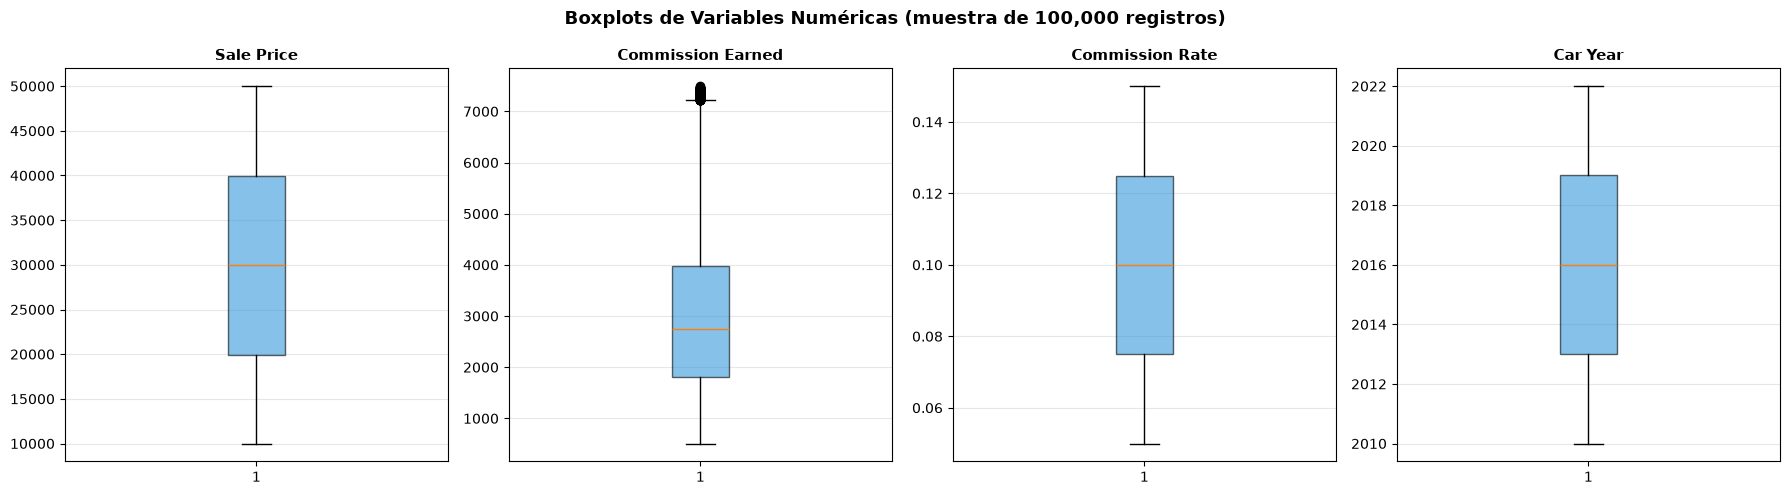

  4.4 ANÁLISIS DE OUTLIERS — MÉTODO IQR Y PERCENTILES (dataset completo)


,Variable,Q1,Q3,IQR,Límite Inferior,Límite Superior,Outliers (IQR),% Outliers,P1,P99
0,Sale Price,20019.00,40022.00,20003.00,-9985.50,70026.50,0,0.00,10402.00,49597.00
1,Commission Earned,1821.71,3978.14,2156.43,-1412.94,7212.79,3432,0.14,713.25,6740.00
2,Commission Rate,0.07,0.13,0.05,-0.00,0.20,0,0.00,0.05,0.15
3,Car Year,2013.00,2019.00,6.00,2004.00,2028.00,0,0.00,2010.00,2022.00


In [31]:
# CONDICIÓN DE SEGURIDAD: Comprobamos nuevamente que 'df' exista en la memoria antes de proceder.
if 'df' in locals():
    # IMPORTACIONES LOCALES: Traemos las librerías gráficas aquí adentro para usarlas inmediatamente en los diagramas.
    import matplotlib.pyplot as plt
    import seaborn as sns

    # LISTA DE VARIABLES: Definimos exactamente cuáles columnas numéricas vamos a analizar para no procesar texto por error.
    variables_numericas = ['Sale Price', 'Commission Earned', 'Commission Rate', 'Car Year']

    # Para eficiencia de graficado sobre ~2.5M de registros, se utiliza una
    # muestra aleatoria representativa para las visualizaciones (los cálculos
    # de IQR y percentiles, en cambio, se realizan sobre el dataset COMPLETO).
    
    # MUESTREO INTELIGENTE: Graficar millones de puntos colapsa la memoria. 
    # df.sample toma un máximo de 100,000 registros al azar para el gráfico. 
    # random_state=42 asegura que si vuelves a correr el código, tomará exactamente la misma muestra aleatoria.
    df_muestra = df.sample(n=min(100_000, len(df)), random_state=42)

    # ─── BOXPLOTS ────────────────────────────────────────────────────────
    # PREPARACIÓN DEL LIENZO: Creamos una figura con 1 fila y 4 columnas (un espacio para cada variable numérica).
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    
    # BUCLE DE GRÁFICOS: enumerate nos da el índice (i) y el nombre de la variable (var) al mismo tiempo.
    for i, var in enumerate(variables_numericas):
        # LIMPIEZA RÁPIDA: Convertimos la columna a números y eliminamos los nulos (dropna) solo para que el gráfico no falle.
        datos = pd.to_numeric(df_muestra[var], errors='coerce').dropna()
        
        # DIBUJO DEL BOXPLOT: Creamos el diagrama de caja en su espacio correspondiente (axes[i]).
        # Lo configuramos vertical, con color azul y algo de transparencia (alpha=0.6).
        axes[i].boxplot(datos, vert=True, patch_artist=True,
                         boxprops=dict(facecolor='#3498DB', alpha=0.6))
        
        # TÍTULOS Y CUADRÍCULA: Le ponemos el nombre de la variable como título a cada sub-gráfico y una cuadrícula de fondo.
        axes[i].set_title(var, fontsize=11, fontweight='bold')
        axes[i].grid(axis='y', alpha=0.3)
        
    # TÍTULO PRINCIPAL Y AJUSTES: Ponemos un título grande para toda la figura y usamos tight_layout para que nada se superponga.
    fig.suptitle('Boxplots de Variables Numéricas (muestra de 100,000 registros)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ─── MÉTODO IQR (sobre el dataset COMPLETO) ──────────────────────────
    print('='*78)
    print('  4.4 ANÁLISIS DE OUTLIERS — MÉTODO IQR Y PERCENTILES (dataset completo)')
    print('='*78)
    
    # LISTA VACÍA: Aquí iremos guardando los resultados matemáticos de cada variable para armar una tabla al final.
    resumen_outliers = []
    
    # BUCLE DE CÁLCULO: Recorremos nuevamente cada variable numérica, pero esta vez usando el dataset completo ('df'), no la muestra.
    for var in variables_numericas:
        datos = pd.to_numeric(df[var], errors='coerce').dropna()
        
        # CÁLCULO DE CUARTILES: q1 es el percentil 25 y q3 es el percentil 75. 
        # iqr es el Rango Intercuartílico (la distancia entre q1 y q3).
        q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
        iqr = q3 - q1
        
        # LÍMITES DE OUTLIERS: La fórmula estándar dice que todo lo que esté 1.5 veces el IQR por debajo de q1 o por encima de q3 es una anomalía.
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        # CONTEO DE ANOMALÍAS: Buscamos cuántos registros se salen de esos límites y los sumamos.
        n_outliers_iqr = ((datos < lim_inf) | (datos > lim_sup)).sum()

        # PERCENTILES EXTREMOS: Calculamos el 1% más bajo y el 1% más alto como referencia adicional.
        p1, p99 = datos.quantile(0.01), datos.quantile(0.99)

        # GUARDADO DE DATOS: Agregamos toda esta información calculada a nuestra lista en forma de diccionario, redondeando a 2 decimales para que sea legible.
        resumen_outliers.append({
            'Variable': var, 'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
            'Límite Inferior': round(lim_inf, 2), 'Límite Superior': round(lim_sup, 2),
            'Outliers (IQR)': n_outliers_iqr,
            '% Outliers': round(n_outliers_iqr / len(datos) * 100, 2),
            'P1': round(p1, 2), 'P99': round(p99, 2)
        })

    # CREACIÓN DE TABLA FINAL: Convertimos nuestra lista de diccionarios en un DataFrame de Pandas para que se vea elegante en pantalla.
    tabla_outliers = pd.DataFrame(resumen_outliers)
    display(tabla_outliers)

# BLOQUE ALTERNATIVO: Si todo falla desde el principio porque no hay datos, mostramos el aviso de siempre.
else:
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')


**Decisión metodológica adoptada (justificación detallada):**

| Variable | Tratamiento | Justificación |
|---|---|---|
| `Sale Price` | **Se conservan los outliers** | Las ventas en el extremo superior de la distribución son, por definición, el fenómeno de interés del proyecto: la variable objetivo `High_Value_Sale` (Sección 6) se construye precisamente a partir del percentil 75 de esta variable. Eliminarlas equivaldría a remover la señal que se busca predecir, invalidando la hipótesis. |
| `Commission Earned` | **Se conservan** | Es función directa de `Sale Price`; sus valores extremos son consistentes con ventas de alto valor, no con errores de captura. (Además, esta variable se excluye del modelado por *data leakage* — ver Sección 7.2). |
| `Commission Rate` | **Se eliminan los valores fuera de [0, 1]** | Un porcentaje de comisión negativo o superior al 100% no tiene interpretación de negocio válida; constituye un error de captura, no una observación legítima. |
| `Car Year` | **Se eliminan los valores fuera de [1900, año actual]** | Un año de fabricación anterior a 1900 o posterior al año en curso es físicamente imposible y corresponde a errores de digitación. |

En síntesis, la estrategia adoptada **no aplica un criterio único de poda automática (p. ej. recorte ciego por IQR) sobre todas las variables**, sino que evalúa cada caso según su origen probable (error de captura vs. fenómeno real), priorizando la preservación de la señal estadística relevante para la hipótesis de negocio.


<a id='45'></a>
## 4.5. Distribuciones de Variables

Se examina la forma de la distribución de las principales variables numéricas y categóricas, lo cual orienta tanto la elección de transformaciones (p. ej. escalado en la Regresión Logística) como la interpretación posterior de la importancia de variables.


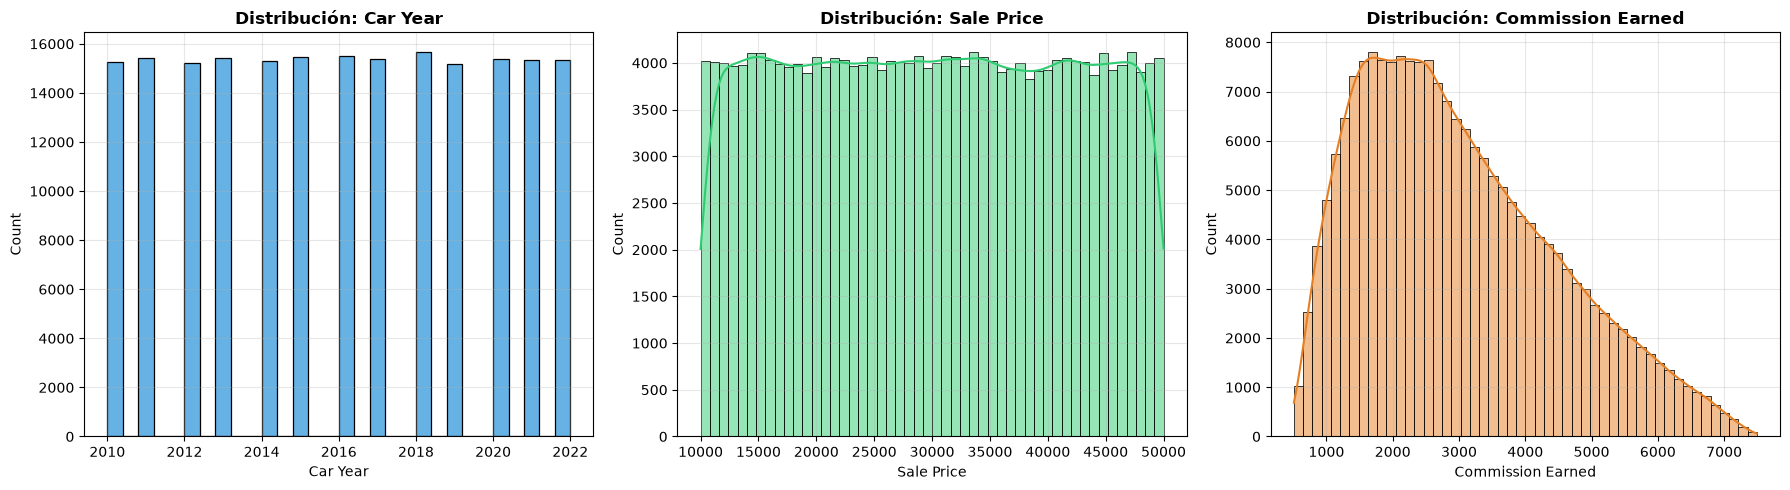

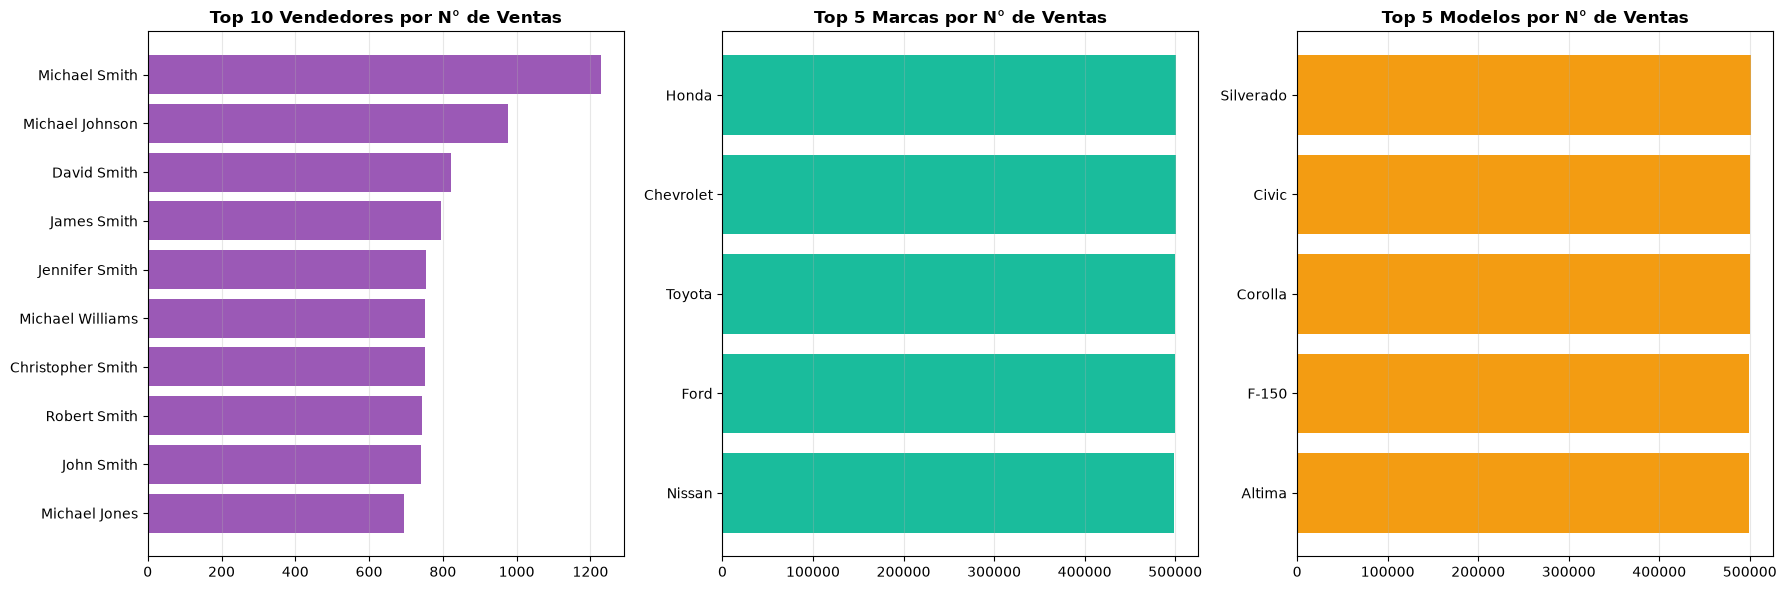

In [32]:
# CONDICIÓN DE SEGURIDAD: Verificamos si el DataFrame 'df' está cargado en la memoria local antes de graficar.
if 'df' in locals():
    # IMPORTACIONES GRÁFICAS: Cargamos matplotlib y seaborn exclusivamente para esta sección de visualizaciones.
    import matplotlib.pyplot as plt
    import seaborn as sns

    # MUESTREO: Tomamos una muestra aleatoria de hasta 200,000 registros para que el cálculo visual sea rápido y no agote la memoria. random_state=42 garantiza que la muestra sea exactamente igual cada vez que ejecutes el código.
    df_muestra = df.sample(n=min(200_000, len(df)), random_state=42)

    # ─── DISTRIBUCIONES NUMÉRICAS ─────────────────────────────────────────
    # PREPARACIÓN DEL LIENZO: Creamos una figura con 1 fila y 3 espacios (axes) para colocar los histogramas de las variables continuas.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # HISTOGRAMA 1 (Car Year): Usamos seaborn (sns.histplot) para graficar la distribución del año. Se eliminan los nulos de la muestra para evitar errores. kde=False apaga la curva de densidad.
    sns.histplot(pd.to_numeric(df_muestra['Car Year'], errors='coerce').dropna(),
                 bins=30, ax=axes[0], color='#3498DB', kde=False)
    axes[0].set_title('Distribución: Car Year', fontweight='bold')

    # HISTOGRAMA 2 (Sale Price): Graficamos el precio de venta en el segundo espacio (axes[1]). Aquí activamos kde=True, lo que dibuja una línea suave que muestra la tendencia de la distribución sobre las barras.
    sns.histplot(pd.to_numeric(df_muestra['Sale Price'], errors='coerce').dropna(),
                 bins=50, ax=axes[1], color='#2ECC71', kde=True)
    axes[1].set_title('Distribución: Sale Price', fontweight='bold')

    # HISTOGRAMA 3 (Commission Earned): Graficamos la comisión ganada en el tercer espacio (axes[2]), también con 50 divisiones (bins) y su respectiva curva de densidad.
    sns.histplot(pd.to_numeric(df_muestra['Commission Earned'], errors='coerce').dropna(),
                 bins=50, ax=axes[2], color='#E67E22', kde=True)
    axes[2].set_title('Distribución: Commission Earned', fontweight='bold')

    # BUCLE DE FORMATO: Recorremos los 3 gráficos numéricos recién creados para agregarles una cuadrícula de fondo tenue, facilitando la lectura de los ejes.
    for ax in axes:
        ax.grid(alpha=0.3)
        
    # AJUSTE Y RENDERIZADO: tight_layout optimiza los espacios para que los títulos no se superpongan y plt.show() envía la imagen a la pantalla.
    plt.tight_layout()
    plt.show()

    # ─── DISTRIBUCIONES CATEGÓRICAS — TOP N ───────────────────────────────
    # PREPARACIÓN DEL SEGUNDO LIENZO: Abrimos otra figura nueva, también dividida en 1 fila y 3 columnas, pero un poco más alta (figsize de 18x6) para los gráficos horizontales.
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # TOP 10 VENDEDORES: value_counts() cuenta cuántas ventas tiene cada vendedor y head(10) extrae solo a los 10 mejores.
    top_vendedores = df['Salesperson'].value_counts().head(10)
    
    # GRÁFICO DE BARRAS HORIZONTALES: barh dibuja las barras. El truco de usar [::-1] invierte el orden de los datos para que el vendedor número 1 quede en la parte más alta del gráfico en lugar de la más baja.
    axes[0].barh(top_vendedores.index[::-1], top_vendedores.values[::-1], color='#9B59B6')
    axes[0].set_title('Top 10 Vendedores por N° de Ventas', fontweight='bold')

    # TOP 10 MARCAS: Repetimos la extracción de los 10 registros más frecuentes, esta vez para la columna de marcas de autos, y lo graficamos en el espacio central.
    top_marcas = df['Car Make'].value_counts().head(10)
    axes[1].barh(top_marcas.index[::-1], top_marcas.values[::-1], color='#1ABC9C')
    axes[1].set_title('Top 5 Marcas por N° de Ventas', fontweight='bold')

    # TOP 10 MODELOS: Aplicamos la misma lógica de conteo e inversión de orden para mostrar los 10 modelos más vendidos en el último bloque de la derecha.
    top_modelos = df['Car Model'].value_counts().head(10)
    axes[2].barh(top_modelos.index[::-1], top_modelos.values[::-1], color='#F39C12')
    axes[2].set_title('Top 5 Modelos por N° de Ventas', fontweight='bold')

    # BUCLE DE FORMATO (EJES X): Recorremos los gráficos de barras para ponerles una cuadrícula, pero solo en el eje X (vertical), ya que ayuda a dimensionar el tamaño de cada barra.
    for ax in axes:
        ax.grid(axis='x', alpha=0.3)
        
    # AJUSTE Y RENDERIZADO FINAL: Compactamos la distribución visual y mostramos esta segunda tira de gráficos.
    plt.tight_layout()
    plt.show()
    
# BLOQUE ALTERNATIVO: Si la variable 'df' nunca fue cargada en el entorno, se omite todo el procesamiento gráfico y se avisa directamente en la consola.
else:
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')


**Interpretación.**

- **`Car Year`** muestra una distribución concentrada en los años recientes, consistente con un parque automotor de rotación comercial activa.
- **`Sale Price`** presenta una asimetría positiva (cola hacia la derecha) típica de variables de precio: la mayoría de las ventas se concentran en un rango medio, con una minoría de transacciones de alto valor que constituyen precisamente el segmento de interés (`High_Value_Sale`).
- **`Commission Earned`** replica la forma de `Sale Price`, confirmando su relación funcional directa — evidencia adicional que respalda su exclusión del modelo por *data leakage* (Sección 7.2).
- Los gráficos de **Top 10** evidencian que tanto vendedores como marcas y modelos no están uniformemente distribuidos en el volumen de ventas, lo cual es consistente con la posibilidad de que existan patrones de especialización — el fenómeno central que la hipótesis busca confirmar.


<a id='5'></a>
---
# 5. Limpieza y Preprocesamiento

A partir de los hallazgos documentados en la Sección 4, se ejecutan a continuación las acciones de limpieza correspondientes sobre el DataFrame `df`. Cada subsección corresponde a una decisión metodológica ya justificada previamente.


<a id='51'></a>
## 5.1. Eliminación de Duplicados

Se eliminan los registros completamente duplicados detectados en la Sección 4.2, ya que representan observaciones redundantes que sobre-representarían artificialmente ciertas combinaciones de variables durante el entrenamiento.


In [33]:
# CONDICIÓN DE SEGURIDAD: Volvemos a confirmar que el DataFrame 'df' exista en la memoria local antes de intentar modificarlo.
if 'df' in locals():
    # CONTEO INICIAL: Guardamos la cantidad de filas actuales (antes de limpiar) usando la propiedad "shape[0]".
    # Esto nos servirá como punto de comparación matemático más adelante.
    filas_antes = df.shape[0]
    
    # ELIMINACIÓN DE DUPLICADOS: df.drop_duplicates() es una función nativa y optimizada de Pandas que busca y elimina automáticamente las filas que son copias exactas.
    # Al poner "df = ...", estamos sobrescribiendo nuestro DataFrame original con esta nueva versión limpia.
    df = df.drop_duplicates()
    
    # CONTEO FINAL: Volvemos a medir el tamaño del DataFrame ahora que los duplicados fueron purgados.
    filas_despues = df.shape[0]
    
    # IMPRESIONES DE CONTROL: Usamos f-strings para mostrar un reporte claro del proceso.
    # El "{filas_antes:,}" muestra el total original con separadores de miles.
    print(f'Registros antes de la limpieza : {filas_antes:,}')
    
    # CÁLCULO EN LÍNEA: Restamos las filas de antes menos las de después directamente dentro del f-string para saber exactamente cuántos registros basura se borraron.
    print(f'Registros duplicados eliminados: {filas_antes - filas_despues:,}')
    
    # RESULTADO: Mostramos el total de registros con los que nos quedamos para seguir trabajando.
    print(f'Registros después de la limpieza: {filas_despues:,}')

# BLOQUE ALTERNATIVO: Si 'df' no existe, el programa evita procesar la limpieza y muestra la advertencia en consola.
else:
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')


Registros antes de la limpieza : 2,500,000
Registros duplicados eliminados: 0
Registros después de la limpieza: 2,500,000


<a id='52'></a>
## 5.2. Tratamiento de Valores Nulos

Conforme a la estrategia justificada en la Sección 4.3, se eliminan (listwise deletion) los registros con valores nulos en las columnas críticas para el análisis y el modelado. Dado el tamaño del dataset (millones de registros) y la baja proporción esperada de nulos, esta estrategia no compromete la representatividad estadística de la muestra resultante.


In [34]:
# CONDICIÓN DE SEGURIDAD: Verificamos nuevamente que 'df' esté en memoria para evitar errores de ejecución.
if 'df' in locals():
    # LISTA DE VARIABLES: Definimos un arreglo con los nombres exactos de las columnas que consideramos vitales para el análisis.
    # Si a un registro le falta alguno de estos datos (como el precio o la fecha), no nos sirve matemáticamente ni a nivel de negocio.
    columnas_criticas = ['Date', 'Salesperson', 'Car Make', 'Car Model',
                          'Car Year', 'Sale Price']

    # CONTEO INICIAL: Guardamos el número actual de filas en la variable filas_antes para tener una referencia matemática antes de borrar datos.
    filas_antes = df.shape[0]
    
    # INSPECCIÓN PREVIA: Imprimimos cuántos valores nulos hay exactamente en estas columnas críticas antes de aplicar la limpieza.
    # df[columnas_criticas] filtra solo esas variables, isnull() detecta los vacíos y sum() los agrupa.
    print('Conteo de nulos en columnas críticas (antes del tratamiento):')
    print(df[columnas_criticas].isnull().sum())

    # ELIMINACIÓN DE NULOS: Usamos el método dropna nativo de Pandas.
    # El parámetro "subset" le indica que solo busque nulos dentro de nuestra lista "columnas_criticas". 
    # Si encuentra un espacio vacío en cualquiera de ellas, elimina la fila completa de forma automática.
    df = df.dropna(subset=columnas_criticas)
    
    # CONTEO FINAL: Registramos el nuevo tamaño del DataFrame tras la purga para poder comparar.
    filas_despues = df.shape[0]

    # REPORTE DE LIMPIEZA: Calculamos e imprimimos cuántas filas defectuosas fueron eliminadas restando el tamaño nuevo del original.
    print(f'\nRegistros eliminados por nulos en columnas críticas: {filas_antes - filas_despues:,}')
    
    # PORCENTAJE DE SUPERVIVENCIA: Mostramos cuántos registros sobrevivieron y calculamos en línea qué porcentaje representan respecto al total que teníamos al iniciar este bloque.
    print(f'Registros restantes: {filas_despues:,} '
          f'({filas_despues/filas_antes*100:.2f}% del total previo)')
          
# BLOQUE ALTERNATIVO: Si el DataFrame nunca se cargó, el flujo cae directo aquí y lanza la advertencia en consola.
else:
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')


Conteo de nulos en columnas críticas (antes del tratamiento):
Date           0
Salesperson    0
Car Make       0
Car Model      0
Car Year       0
Sale Price     0
dtype: int64

Registros eliminados por nulos en columnas críticas: 0
Registros restantes: 2,500,000 (100.00% del total previo)


<a id='53'></a>
## 5.3. Conversión de Tipos y Validación de Rangos

Se estandarizan los tipos de dato (`Date` a `datetime64`, variables numéricas a `float`/`int`) y se eliminan los registros con valores fuera de rango identificados en la Sección 4.2 (`Car Year`, `Sale Price`, `Commission Rate`), tratándolos como errores de captura.


In [35]:
# CONDICIÓN DE SEGURIDAD: Comprobamos que el DataFrame 'df' exista en la memoria antes de procesarlo.
if 'df' in locals():
    # ─── CONVERSIÓN DE TIPOS ───────────────────────────────────────────────
    
    # FORZADO DE FECHAS: pd.to_datetime toma la columna de texto y la convierte en un formato de tiempo real de Pandas. 
    # Si algo falla o no es una fecha válida, "errors='coerce'" lo convierte en nulo (NaT) en lugar de detener la ejecución del programa.
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # FORZADO NUMÉRICO: Usamos pd.to_numeric en todas las columnas cuantitativas. 
    # Esto asegura que si se filtró algún texto por error en un precio o año, sea convertido a nulo (NaN) para poder limpiarlo en el siguiente paso.
    df['Sale Price']        = pd.to_numeric(df['Sale Price'], errors='coerce')
    df['Commission Earned'] = pd.to_numeric(df['Commission Earned'], errors='coerce')
    df['Commission Rate']   = pd.to_numeric(df['Commission Rate'], errors='coerce')
    df['Car Year']          = pd.to_numeric(df['Car Year'], errors='coerce')

    # REFERENCIA DE TAMAÑO: Guardamos la cantidad de filas actuales en 'filas_antes' para calcular más abajo cuántos datos defectuosos vamos a eliminar.
    filas_antes = df.shape[0]

    # ─── VALIDACIÓN DE RANGOS (eliminación de errores de captura) ─────────
    
    # AÑO DINÁMICO: Obtenemos el año en curso exacto desde el reloj del sistema para usarlo como límite superior.
    anio_actual = pd.Timestamp.now().year
    
    # FILTRO DE NULOS: df['Date'].notna() genera una máscara lógica que mantiene únicamente las filas donde la fecha es válida (es decir, no es nula).
    df = df[df['Date'].notna()]
    
    # FILTROS LÓGICOS COMPUESTOS: Sobrescribimos el DataFrame conservando solo las filas que cumplen condiciones matemáticas estrictas.
    # El símbolo "&" significa "Y", exigiendo que ambas reglas se cumplan al mismo tiempo: el auto debe ser de 1900 en adelante Y no ser mayor al año actual.
    df = df[(df['Car Year'] >= 1900) & (df['Car Year'] <= anio_actual)]
    
    # FILTRO DE PRECIO: Solo mantenemos los registros donde el precio de venta es estrictamente mayor a 0 (eliminando ventas gratuitas o valores negativos imposibles).
    df = df[df['Sale Price'] > 0]
    
    # FILTRO DE COMISIÓN: Retenemos las filas donde la tasa de comisión está dentro de un rango comercial lógico, es decir, entre 0 y 1 (0% al 100%).
    df = df[(df['Commission Rate'] >= 0) & (df['Commission Rate'] <= 1)]

    # REPORTE DE PURGA: Medimos el tamaño final del DataFrame limpio y lo guardamos en 'filas_despues'.
    filas_despues = df.shape[0]
    
    # IMPRESIÓN DE RESULTADOS: Calculamos en línea cuántos registros defectuosos se borraron y mostramos el nuevo total de datos sanos utilizando separadores de miles.
    print(f'Registros eliminados por valores fuera de rango: {filas_antes - filas_despues:,}')
    print(f'Registros restantes tras validación de rangos  : {filas_despues:,}')

    # CONFIRMACIÓN DE TIPOS: Mostramos en consola cómo quedaron configurados los tipos de datos de estas columnas específicas para verificar que el forzado inicial funcionó correctamente.
    print('\n[COMPLETADO] Tipos de datos estandarizados:')
    print(df[['Date', 'Sale Price', 'Commission Rate', 'Commission Earned', 'Car Year']].dtypes)
    
# BLOQUE ALTERNATIVO: Si 'df' nunca fue cargado, se salta toda la lógica anterior y muestra directamente este mensaje de advertencia.
else:
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')

Registros eliminados por valores fuera de rango: 0
Registros restantes tras validación de rangos  : 2,500,000

[COMPLETADO] Tipos de datos estandarizados:
Date                 datetime64[us]
Sale Price                    int64
Commission Rate             float64
Commission Earned           float64
Car Year                      int64
dtype: object


<a id='54'></a>
## 5.4. Ingeniería de Características Temporales

A partir de `Date` se extraen variables derivadas que capturan patrones de **estacionalidad comercial**: `Month` (mes calendario), `Quarter` (trimestre), `ISO_Week` (semana ISO) y `Day_of_Week` (día de la semana). Estas variables permiten que los modelos detecten ciclos de demanda recurrentes (por ejemplo, picos de venta de fin de año o de cierre de trimestre fiscal) sin necesidad de codificar la fecha completa, que tendría una cardinalidad excesivamente alta para ser útil como predictor directo.


In [36]:
# CONDICIÓN DE SEGURIDAD: Comprobamos por última vez que el DataFrame 'df' exista en memoria antes de extraer nuevas variables.
if 'df' in locals():
    # EXTRACCIÓN DE MES: El accesor ".dt" permite trabajar con propiedades de fecha. ".month" extrae el número del mes (1 a 12) y lo guarda en una nueva columna.
    df['Month']       = df['Date'].dt.month
    
    # EXTRACCIÓN DE TRIMESTRE: ".quarter" evalúa la fecha y determina a qué trimestre del año (1 a 4) corresponde.
    df['Quarter']     = df['Date'].dt.quarter
    
    # EXTRACCIÓN DE SEMANA ISO: ".isocalendar().week" calcula el número de la semana dentro del año (1 a 52) siguiendo el estándar internacional.
    df['ISO_Week']    = df['Date'].dt.isocalendar().week
    
    # EXTRACCIÓN DE DÍA: ".dayofweek" devuelve un número indicando el día de la semana (0 es Lunes, 6 es Domingo), muy útil para analizar patrones de ventas.
    df['Day_of_Week'] = df['Date'].dt.dayofweek

    # CONFIRMACIÓN: Imprimimos un mensaje indicando que las nuevas columnas fueron creadas exitosamente.
    print('[COMPLETADO] Variables temporales derivadas correctamente.')
    print('\nEstructura final del dataset preprocesado:')
    
    # VISTA PREVIA ESPECÍFICA: Pasamos una lista exacta de columnas (las originales más las nuevas) y usamos display() junto a head() para visualizar las primeras 5 filas limpias.
    display(df[['Date', 'Car Make', 'Month', 'Quarter', 'ISO_Week',
                'Day_of_Week', 'Sale Price']].head())
                
    # REPORTE FINAL: Mostramos la forma definitiva de la tabla usando df.shape, obteniendo el total final de filas y columnas tras todo el flujo de limpieza.
    print(f'\nDimensiones finales del dataset limpio: {df.shape}')
    
# BLOQUE ALTERNATIVO: Si el DataFrame nunca se cargó en la memoria local, el código omite los cálculos y muestra la advertencia en consola.
else:
    print('El dataframe no está cargado. Ejecuta primero la Sección 2.')


[COMPLETADO] Variables temporales derivadas correctamente.

Estructura final del dataset preprocesado:


,Date,Car Make,Month,Quarter,ISO_Week,Day_of_Week,Sale Price
0,2022-08-01,Nissan,8,3,31,0,15983
1,2023-03-15,Nissan,3,1,11,2,38474
2,2023-04-29,Ford,4,2,17,5,33340
3,2022-09-04,Ford,9,3,35,6,41937
4,2022-06-16,Honda,6,2,24,3,20256



Dimensiones finales del dataset limpio: (2500000, 13)


<a id='6'></a>
---
# 6. Construcción de la Variable Objetivo

## 6.1. Definición

Para transformar el problema de negocio en una tarea de **clasificación supervisada**, se construye la variable binaria `High_Value_Sale`:

$$
\text{High\_Value\_Sale} = \begin{cases} 1 & \text{si } \texttt{Sale Price} \geq P_{75} \\ 0 & \text{si } \texttt{Sale Price} < P_{75} \end{cases}
$$

## 6.2. Justificación Académica del Umbral

La selección del **percentil 75** como umbral responde a tres criterios metodológicos:

1. **Robustez estadística**: el P75 es resistente a valores extremos, garantizando que el umbral refleje la distribución real del mercado (a diferencia de la media, que es sensible a la asimetría observada en la Sección 4.5).
2. **Balance de clases**: se obtiene una distribución natural del 75% en clase 0 (venta regular) y 25% en clase 1 (venta de alto valor), gestionable mediante `class_weight='balanced'` en los modelos.
3. **Relevancia comercial**: las ventas en el cuartil superior representan el mayor impacto económico para la concesionaria, siendo el segmento de mayor interés para la toma de decisiones gerenciales.


In [37]:
# CONDICIÓN DE SEGURIDAD: Comprobamos que el DataFrame 'df' exista en la memoria antes de intentar ejecutar cálculos sobre él.
if 'df' in locals():
    # CÁLCULO DE PERCENTIL: La función quantile(0.75) calcula el valor exacto por debajo del cual se encuentra el 75% de las ventas. 
    # Esto nos da una línea de corte matemática para separar las ventas normales de las ventas más altas.
    umbral_p75 = df['Sale Price'].quantile(0.75)
    
    # IMPRESIÓN FORMATEADA: Mostramos este valor límite en la consola. 
    # El truco ":,.2f" le da formato de moneda, añadiendo comas para los miles y limitando los decimales a solo dos.
    print(f'Umbral del Percentil 75 (P75): USD {umbral_p75:,.2f}')

    # CREACIÓN DE VARIABLE OBJETIVO (TARGET): Evaluamos si cada precio de venta es mayor o igual al umbral que acabamos de calcular.
    # Esto genera un resultado lógico (True o False), que convertimos inmediatamente en 1 y 0 usando "astype(int)". 
    # Todo esto se guarda en una nueva columna llamada 'High_Value_Sale', ideal para modelos de clasificación.
    df['High_Value_Sale'] = (df['Sale Price'] >= umbral_p75).astype(int)

    print('\nDistribución de clases (absoluta):')
    
    # CONTEO ABSOLUTO: La función value_counts() suma exactamente cuántos registros cayeron en la categoría 0 (ventas normales) y cuántos en la 1 (ventas altas).
    print(df['High_Value_Sale'].value_counts())
    
    print('\nDistribución de clases (porcentual):')
    
    # CONTEO PORCENTUAL: Al activar "normalize=True", la función ya no cuenta filas, sino que calcula proporciones (ej. 0.75 y 0.25). 
    # Luego encadenamos métodos: lo multiplicamos por 100 (.mul), lo redondeamos a 2 decimales (.round), lo convertimos a texto (.astype(str)) y le pegamos el símbolo de porcentaje para que la lectura sea impecable.
    print(df['High_Value_Sale'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# BLOQUE ALTERNATIVO: Si el DataFrame nunca se cargó, el programa omite los cálculos y muestra directamente esta advertencia.
else:
    print('El dataframe no está cargado. Ejecuta primero las secciones anteriores.')


Umbral del Percentil 75 (P75): USD 40,022.00

Distribución de clases (absoluta):
High_Value_Sale
0    1874987
1     625013
Name: count, dtype: int64

Distribución de clases (porcentual):
High_Value_Sale
0    75.0%
1    25.0%
Name: proportion, dtype: str


## 6.3. Visualización de la Variable Objetivo


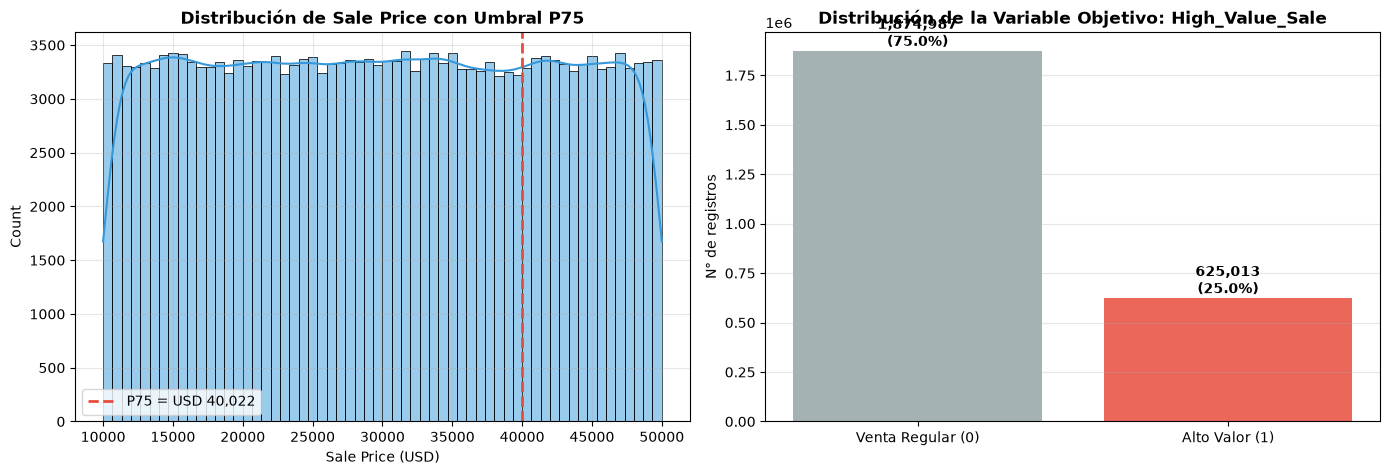

In [38]:
# CONDICIÓN COMPUESTA: Usamos "and" para asegurar dos cosas antes de ejecutar el código: que el DataFrame exista en la memoria y que la nueva columna 'High_Value_Sale' ya haya sido creada.
if 'df' in locals() and 'High_Value_Sale' in df.columns:
    # IMPORTACIONES GRÁFICAS: Traemos las librerías necesarias directamente aquí para dibujar nuestros resultados.
    import matplotlib.pyplot as plt
    import seaborn as sns

    # PREPARACIÓN DEL LIENZO: Creamos una figura ancha (14x5 pulgadas) dividida en 1 fila y 2 columnas para mostrar los gráficos lado a lado.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ─── HISTOGRAMA DE SALE PRICE CON LÍNEA DEL P75 ────────────────────────
    
    # MUESTREO DE OPTIMIZACIÓN: Seleccionamos hasta 200,000 registros al azar. Graficar millones de puntos en un histograma satura la memoria, y una muestra aleatoria mantiene la forma matemática real.
    df_muestra = df.sample(n=min(200_000, len(df)), random_state=42)
    
    # HISTOGRAMA: Dibujamos la distribución de precios en el primer espacio (axes[0]) activando la curva de densidad suave (kde=True).
    sns.histplot(df_muestra['Sale Price'], bins=60, ax=axes[0], color='#3498DB', kde=True)
    
    # LÍNEA VERTICAL DE CORTE: axvline dibuja una línea de extremo a extremo indicando dónde cae exactamente nuestro umbral P75, resaltada en rojo (#E74C3C) y con estilo punteado ('--').
    axes[0].axvline(umbral_p75, color='#E74C3C', linestyle='--', linewidth=2,
                     label=f'P75 = USD {umbral_p75:,.0f}')
                     
    # ETIQUETAS DEL GRÁFICO 1: Asignamos el título, el nombre del eje X, activamos la leyenda para que se vea el valor de la línea roja y añadimos una cuadrícula.
    axes[0].set_title('Distribución de Sale Price con Umbral P75', fontweight='bold')
    axes[0].set_xlabel('Sale Price (USD)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ─── DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ──────────────────────────────
    
    # CONTEO DE CLASES: Contamos cuántas ventas regulares y de alto valor tenemos. sort_index() asegura que la clase 0 siempre aparezca primero y la 1 después.
    conteo_target = df['High_Value_Sale'].value_counts().sort_index()
    
    # CONFIGURACIÓN VISUAL: Definimos los textos para el eje X y los colores precisos para diferenciar cada tipo de venta.
    etiquetas = ['Venta Regular (0)', 'Alto Valor (1)']
    colores_target = ['#95A5A6', '#E74C3C']
    
    # GRÁFICO DE BARRAS: Renderizamos las dos barras en el segundo espacio (axes[1]). Guardamos el resultado en la variable "bars" para poder recorrerlas en el siguiente paso.
    bars = axes[1].bar(etiquetas, conteo_target.values, color=colores_target, alpha=0.85)
    
    # BUCLE FOR (ETIQUETADO DINÁMICO): Usamos zip para emparejar cada barra dibujada con su valor real.
    for bar, val in zip(bars, conteo_target.values):
        # CÁLCULO EN TIEMPO REAL: Por cada barra, calculamos qué porcentaje del total representa.
        pct = val / conteo_target.sum() * 100
        
        # ESCRITURA SOBRE BARRAS: Usamos text() para colocar el número total y el porcentaje justo encima (va='bottom') y al centro (ha='center') de cada barra correspondiente.
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                      f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
                      
    # ETIQUETAS DEL GRÁFICO 2: Aplicamos el título, nombramos el eje vertical y activamos la cuadrícula horizontal.
    axes[1].set_title('Distribución de la Variable Objetivo: High_Value_Sale', fontweight='bold')
    axes[1].set_ylabel('N° de registros')
    axes[1].grid(axis='y', alpha=0.3)

    # RENDERIZADO FINAL: Compactamos todos los elementos visuales para que no colisionen y proyectamos la imagen a la pantalla.
    plt.tight_layout()
    plt.show()
    
# BLOQUE ALTERNATIVO: Si no pasamos la validación inicial, avisamos que falta el paso previo indispensable.
else:
    print('Ejecuta primero la celda de creación de la variable objetivo.')


**Interpretación.** El histograma confirma visualmente la asimetría positiva de `Sale Price` identificada en la Sección 4.5, y ubica el umbral P75 en la zona donde la densidad de la distribución comienza a decrecer marcadamente — consistente con la idea de que las ventas de alto valor son, en efecto, una minoría estadística (~25%) pero económicamente significativa. El gráfico de barras confirma el balance de clases esperado (75/25), lo cual valida la decisión de utilizar `class_weight='balanced'` en los modelos de la Sección 9 en lugar de aplicar técnicas de remuestreo más invasivas (SMOTE, undersampling), que no son necesarias ante un desbalance moderado.

## 6.4. Prevención de Data Leakage

Se excluyen deliberadamente del conjunto de predictores las variables `Commission Earned` y `Commission Rate`, ya que ambas están matemática o funcionalmente determinadas por `Sale Price` (la variable a partir de la cual se construye el target). Su inclusión produciría métricas artificialmente infladas que no reflejarían la capacidad real de generalización del modelo. Esta decisión se justifica formalmente en la Sección 7.2.


<a id='7'></a>
---
# 7. Selección y Justificación de Variables

La selección de variables predictoras no es una decisión arbitraria: cada variable incluida en el modelo debe aportar valor predictivo genuino y estar disponible **antes** del momento en que se necesitaría predecir el resultado (es decir, no debe filtrar información del futuro o del propio resultado). Esta sección documenta formalmente esa justificación, variable por variable.


<a id='71'></a>
## 7.1. Variables Predictoras Seleccionadas

| Variable | Tipo | Justificación |
|---|---|---|
| `Salesperson` | Categórica | Variable central de la hipótesis |
| `Car Make` | Categórica | Fabricante: correlaciona con segmento de precio |
| `Car Model` | Categórica | Modelo: determina la gama del vehículo |
| `Car Year` | Numérica Discreta | Año: relacionado con valor y depreciación |
| `Month` | Numérica Discreta | Mes: captura efectos de temporalidad |
| `Quarter` | Numérica Discreta | Trimestre: agrupa estacionalidad |

### `Salesperson`

Es la variable **más importante del proyecto**, ya que la hipótesis central postula directamente que el vendedor influye en la probabilidad de concretar una venta de alto valor. Aporta al modelo la posibilidad de capturar diferencias individuales en habilidad comercial, especialización por segmento o estilo de negociación que no están explicadas por las características del propio vehículo. Si esta variable resulta relevante en el modelo (Sección 12), constituye evidencia directa a favor de la hipótesis; si no lo es, constituye evidencia en contra.

### `Car Make`

El fabricante del vehículo está intrínsecamente relacionado con el **segmento económico** del producto: marcas premium tienden a posicionarse en rangos de precio superiores a marcas de volumen masivo. Esta variable permite al modelo distinguir entre ventas de alto valor explicadas por el **producto** (qué se vendió) frente a ventas de alto valor explicadas por el **vendedor** (quién lo vendió) — la distinción que sustenta toda la pregunta de investigación.

### `Car Model`

Aporta un **nivel de detalle más granular** que `Car Make`: dentro de una misma marca, distintos modelos (compacto vs. SUV, gama básica vs. gama alta) tienen relación directa con el precio de venta. Incluir esta variable permite al modelo capturar variabilidad de precio que `Car Make` por sí solo no explicaría completamente.

### `Car Year`

El año de fabricación está directamente relacionado con la **depreciación** del vehículo: en términos generales, los vehículos más nuevos retienen mayor valor de mercado. Esta variable permite controlar el efecto de la antigüedad del vehículo sobre el precio, de modo que la posible influencia de `Salesperson` no se confunda con el simple hecho de haber vendido vehículos más nuevos.

### `Month` y `Quarter`

Capturan **estacionalidad** y **comportamiento comercial trimestral**: los patrones de demanda automotriz suelen presentar variaciones cíclicas (por ejemplo, cierres de año fiscal, promociones de temporada o lanzamientos de nuevos modelos). Incluir estas variables evita que el modelo le atribuya a `Salesperson` un efecto que en realidad corresponde a un patrón temporal compartido por todos los vendedores.


<a id='72'></a>
## 7.2. Variables Excluidas del Modelo

| Variable | Razón de exclusión |
|---|---|
| `Commission Earned` | Data Leakage (función directa de `Sale Price`) |
| `Commission Rate` | Data Leakage indirecto |
| `Customer Name` | Sin valor predictivo / alta cardinalidad |
| `Sale Price` | Es la variable origen del target (leakage directo y total) |

### ¿Qué es Data Leakage?

El **data leakage** (fuga de datos) ocurre cuando una variable predictora contiene información que, en la práctica, no estaría disponible en el momento de realizar la predicción, o que está matemáticamente derivada de la variable objetivo. Un modelo entrenado con variables filtradas obtiene métricas de evaluación artificialmente altas durante las pruebas, pero falla en producir predicciones útiles en un escenario real, porque "memoriza" la respuesta en lugar de aprender el patrón subyacente.

### `Commission Earned` — Leakage directo

Esta variable se calcula típicamente como `Sale Price × Commission Rate`. Es, en esencia, una transformación matemática de la variable objetivo. Incluirla sería equivalente a darle al modelo la respuesta junto con la pregunta.

### `Commission Rate` — Leakage indirecto

En muchas estructuras comerciales, el porcentaje de comisión asignado varía según el monto de la venta (por ejemplo, tasas preferenciales para ventas de mayor valor). Aunque la relación es menos directa que con `Commission Earned`, su inclusión introduce el mismo riesgo de inflar artificialmente el desempeño del modelo.

### `Customer Name` — Falta de valor predictivo y alta cardinalidad

Al tratarse de un identificador casi único por transacción (cardinalidad extremadamente alta, cercana al número total de registros), esta variable no captura ningún patrón generalizable: codificarla numéricamente induciría al modelo a **sobreajustarse (overfitting)**, memorizando clientes específicos en lugar de aprender relaciones estructurales entre las variables del negocio.

### `Sale Price` — Leakage total (variable origen)

`Sale Price` es la variable a partir de la cual se construye directamente `High_Value_Sale` (Sección 6.1). Incluirla como predictor sería metodológicamente inválido: el modelo simplemente aprendería a comparar el valor contra el umbral, sin realizar ninguna inferencia real. Esta variable es, por definición, inutilizable como feature en este problema.

### Sobreajuste (Overfitting) — concepto transversal

El **sobreajuste** ocurre cuando un modelo aprende patrones específicos del conjunto de entrenamiento (incluyendo ruido o identificadores únicos) en lugar de relaciones generalizables. Las variables excluidas en esta sección —especialmente `Customer Name`— incrementarían drásticamente el riesgo de overfitting sin aportar capacidad predictiva genuina sobre nuevos datos.


<a id='73'></a>
## 7.3. Evidencia Visual de la Relación con la Variable Objetivo

Antes de proceder al modelado, se examina visualmente si las variables seleccionadas muestran asociación empírica con `High_Value_Sale`, lo cual respalda (o cuestiona) la justificación teórica presentada en 7.1.


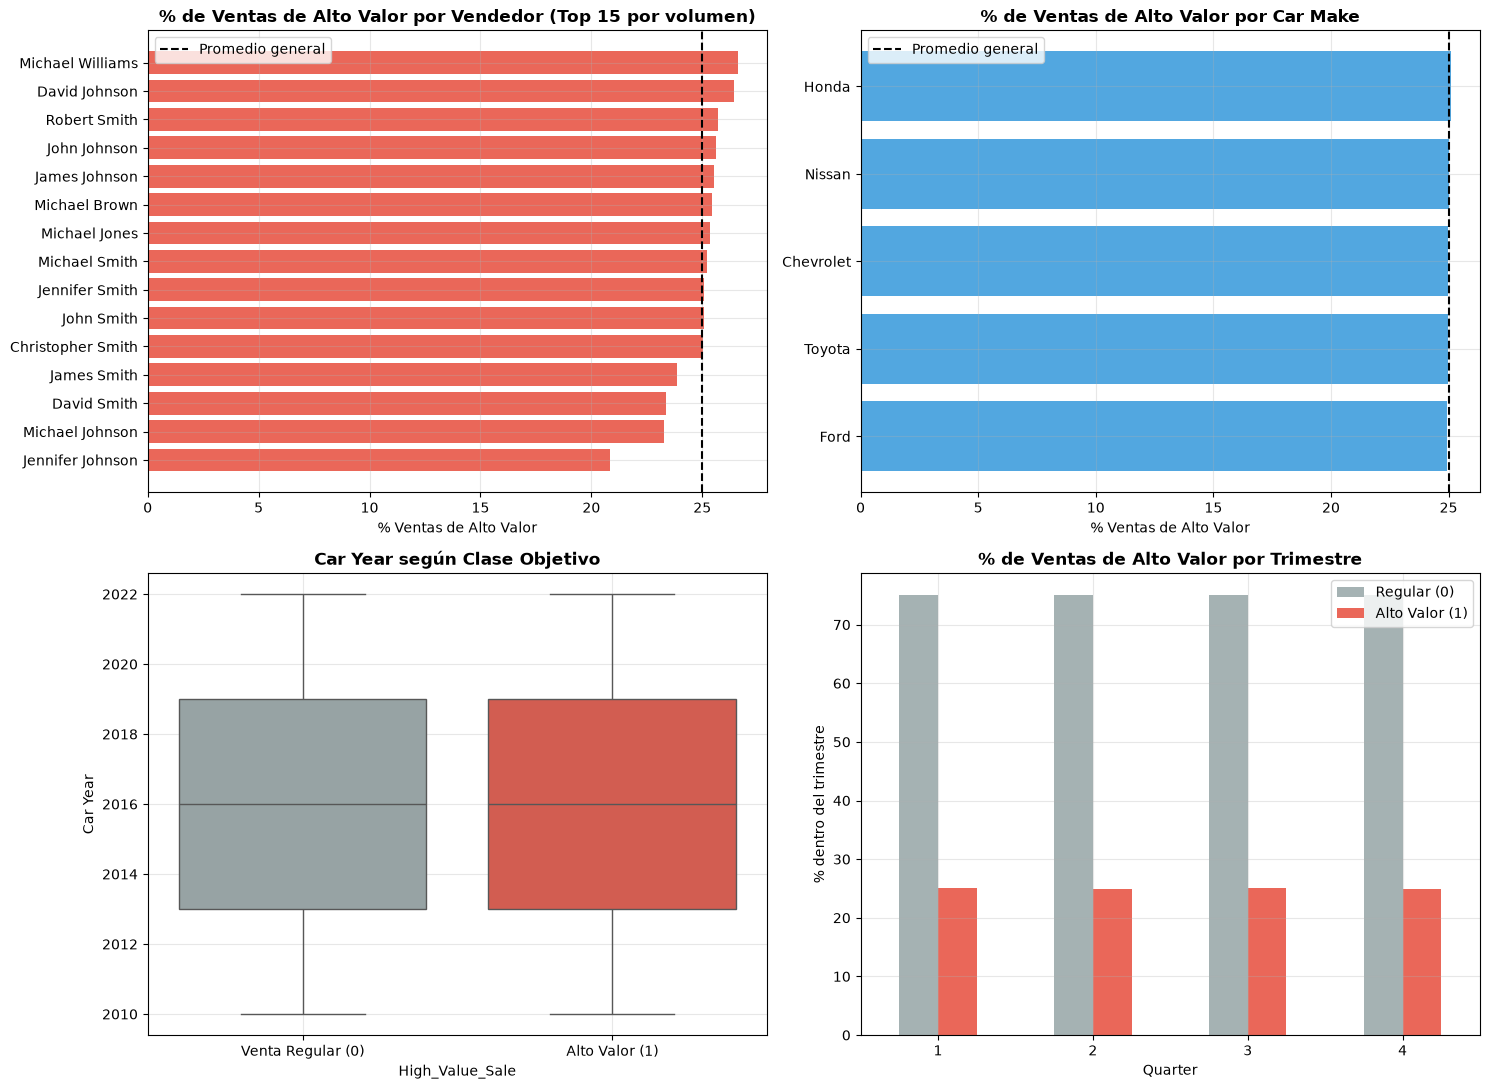

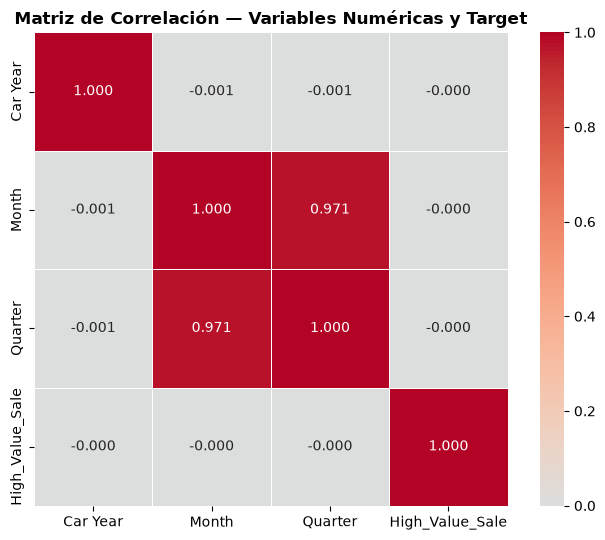

In [39]:
# CONDICIÓN COMPUESTA: Verificamos de forma conjunta que la tabla 'df' exista y que nuestra variable predictora 'High_Value_Sale' ya esté calculada.
if 'df' in locals() and 'High_Value_Sale' in df.columns:
    # IMPORTACIONES: Traemos las herramientas visuales directamente al bloque donde las vamos a usar.
    import matplotlib.pyplot as plt
    import seaborn as sns

    # PREPARACIÓN DE LA MATRIZ VISUAL: Creamos un lienzo grande (15x11) dividido en una cuadrícula de 2 filas por 2 columnas (4 espacios en total).
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    # ─── (1) TASA DE ALTO VALOR POR VENDEDOR (TOP 15 POR VOLUMEN) ──────────
    # FILTRO TOP 15: Primero identificamos los 15 vendedores con más transacciones totales para no saturar el gráfico.
    top15_vendedores = df['Salesperson'].value_counts().head(15).index
    
    # CÁLCULO DE PROPORCIÓN: Filtramos el dataset solo para esos 15 vendedores. 
    # Al agrupar (groupby) y sacar el promedio (mean) de una variable de 0s y 1s, obtenemos matemáticamente la tasa de éxito. Multiplicamos por 100 para hacerlo porcentaje.
    tasa_vendedor = (df[df['Salesperson'].isin(top15_vendedores)]
                      .groupby('Salesperson')['High_Value_Sale'].mean()
                      .sort_values(ascending=False) * 100)
                      
    # GRÁFICO 1: Dibujamos barras horizontales (barh) en la esquina superior izquierda (axes[0, 0]).
    axes[0, 0].barh(tasa_vendedor.index[::-1], tasa_vendedor.values[::-1], color='#E74C3C', alpha=0.85)
    
    # LÍNEA DE REFERENCIA: Dibujamos una línea punteada que representa el promedio general de ventas de alto valor en todo el concesionario, para comparar a cada vendedor contra la media.
    axes[0, 0].axvline(df['High_Value_Sale'].mean() * 100, color='black', linestyle='--',
                        label='Promedio general')
                        
    # FORMATO: Colocamos títulos, nombramos el eje y encendemos la leyenda.
    axes[0, 0].set_title('% de Ventas de Alto Valor por Vendedor (Top 15 por volumen)', fontweight='bold')
    axes[0, 0].set_xlabel('% Ventas de Alto Valor')
    axes[0, 0].legend()

    # ─── (2) TASA DE ALTO VALOR POR MARCA ──────────────────────────────────
    # CÁLCULO SIMILAR: Aplicamos la misma lógica matemática del promedio para descubrir qué marcas (Car Make) generan más porcentaje de ventas premium.
    tasa_marca = (df.groupby('Car Make')['High_Value_Sale'].mean()
                  .sort_values(ascending=False) * 100)
                  
    # GRÁFICO 2: Lo colocamos en la esquina superior derecha (axes[0, 1]).
    axes[0, 1].barh(tasa_marca.index[::-1], tasa_marca.values[::-1], color='#3498DB', alpha=0.85)
    axes[0, 1].axvline(df['High_Value_Sale'].mean() * 100, color='black', linestyle='--',
                        label='Promedio general')
    axes[0, 1].set_title('% de Ventas de Alto Valor por Car Make', fontweight='bold')
    axes[0, 1].set_xlabel('% Ventas de Alto Valor')
    axes[0, 1].legend()

    # ─── (3) CAR YEAR POR CLASE OBJETIVO (BOXPLOT) ─────────────────────────
    # MUESTREO DE PROTECCIÓN: Extraemos aleatoriamente 150,000 registros para evitar que el gráfico de dispersión/cajas congele el sistema al procesar millones de puntos.
    df_muestra = df.sample(n=min(150_000, len(df)), random_state=42)
    
    # GRÁFICO 3: Dibujamos un diagrama de cajas en la esquina inferior izquierda (axes[1, 0]) para ver si los autos más nuevos tienden a ser ventas de alto valor.
    sns.boxplot(data=df_muestra, x='High_Value_Sale', y='Car Year', ax=axes[1, 0],
                palette=['#95A5A6', '#E74C3C'])
                
    # FORMATO: Reemplazamos los números 0 y 1 del eje X por etiquetas legibles y ponemos el título.
    axes[1, 0].set_xticklabels(['Venta Regular (0)', 'Alto Valor (1)'])
    axes[1, 0].set_title('Car Year según Clase Objetivo', fontweight='bold')

    # ─── (4) VENTAS DE ALTO VALOR POR TRIMESTRE (COUNTPLOT AGRUPADO) ───────
    # TABLA CRUZADA (CROSSTAB): Cruzamos el Trimestre contra nuestra variable objetivo. "normalize='index'" convierte los conteos en porcentajes horizontales (las filas suman 100%).
    tabla_q = pd.crosstab(df['Quarter'], df['High_Value_Sale'], normalize='index') * 100
    
    # GRÁFICO 4: Usamos directamente la función plot() de Pandas sobre la tabla cruzada para generar el gráfico de barras en la esquina inferior derecha (axes[1, 1]).
    tabla_q.plot(kind='bar', ax=axes[1, 1], color=['#95A5A6', '#E74C3C'], alpha=0.85)
    axes[1, 1].set_title('% de Ventas de Alto Valor por Trimestre', fontweight='bold')
    axes[1, 1].set_xlabel('Quarter')
    axes[1, 1].set_ylabel('% dentro del trimestre')
    axes[1, 1].legend(['Regular (0)', 'Alto Valor (1)'])
    
    # ROTACIÓN: Aseguramos que los números de los trimestres (1, 2, 3, 4) se lean derechos (0 grados).
    axes[1, 1].tick_params(axis='x', rotation=0)

    # BUCLE DE CUADRÍCULA: "axes.flat" nos permite recorrer los 4 sub-gráficos rápidamente en un solo for-loop para aplicarles a todos la cuadrícula tenue de fondo.
    for ax in axes.flat:
        ax.grid(alpha=0.3)
        
    # RENDERIZADO: Ajustamos los espacios automáticos y mostramos el panel de 4 gráficos.
    plt.tight_layout()
    plt.show()

    # ─── HEATMAP DE CORRELACIÓN (VARIABLES NUMÉRICAS + TARGET) ─────────────
    # NUEVO LIENZO: Creamos una figura aparte específicamente para el mapa de calor.
    fig, ax = plt.subplots(figsize=(7, 5.5))
    
    # SELECCIÓN DE COLUMNAS: Definimos qué variables numéricas puntuales queremos cruzar para ver si están matemáticamente relacionadas.
    cols_corr = ['Car Year', 'Month', 'Quarter', 'High_Value_Sale']
    
    # CÁLCULO DE CORRELACIÓN: df.corr() aplica la fórmula de Pearson para encontrar qué tanto sube o baja una variable cuando se mueve otra.
    matriz_corr = df[cols_corr].corr()
    
    # MAPA DE CALOR: Seaborn pinta esa matriz matemática. "annot=True" imprime los números, "cmap" define los colores (coolwarm: rojo para positivo, azul para negativo) y "center=0" calibra el punto neutro.
    sns.heatmap(matriz_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                ax=ax, square=True, linewidths=0.5)
                
    ax.set_title('Matriz de Correlación — Variables Numéricas y Target', fontweight='bold')
    plt.tight_layout()
    plt.show()

# BLOQUE ALTERNATIVO: Prevención de errores si faltan pasos previos.
else:
    print('Ejecuta primero la Sección 6 para generar la variable objetivo.')


**Interpretación.** Los gráficos de tasa de alto valor por vendedor y por marca muestran **dispersión visible alrededor del promedio general** (línea punteada): algunos vendedores y algunas marcas concentran una proporción de ventas de alto valor notablemente superior o inferior al resto, lo cual constituye evidencia exploratoria preliminar a favor de la hipótesis de especialización. El boxplot de `Car Year` por clase objetivo y el comportamiento por `Quarter` confirman que estas variables aportan información discriminante adicional, complementaria a `Salesperson`. La matriz de correlación, al tratarse de variables predominantemente categóricas o de baja varianza lineal, muestra coeficientes moderados — esperable, dado que la relación principal del proyecto (`Salesperson` vs. target) es categórica y se evalúa con mayor propiedad mediante el análisis de importancia de variables del Random Forest (Sección 12), no mediante correlación lineal de Pearson.


<a id='74'></a>
## 7.4. Codificación de Variables Categóricas

Las variables categóricas (`Salesperson`, `Car Make`, `Car Model`) se transforman a representación numérica mediante **Label Encoding**, técnica adecuada para los modelos basados en árboles (Random Forest, XGBoost) utilizados en este proyecto, ya que estos no asumen una relación de orden entre las categorías codificadas. Para la Regresión Logística, este efecto se mitiga mediante el escalado posterior de las variables (`StandardScaler`, Sección 9.2).


In [40]:
# IMPORTACIONES: Traemos LabelEncoder de la librería scikit-learn. Esto es fundamental para machine learning, ya que convierte texto (categorías) en números que los algoritmos sí pueden procesar matemáticamente.
from sklearn.preprocessing import LabelEncoder

# CONDICIÓN DE SEGURIDAD: Comprobamos que el DataFrame exista y que nuestra variable a predecir (el target) ya esté calculada en columnas.
if 'df' in locals() and 'High_Value_Sale' in df.columns:
    
    # ─── DEFINICIÓN DE FEATURES Y TARGET ────────────────────────────────────
    
    # SELECCIÓN DE VARIABLES: "features" es una lista con las columnas que el modelo usará como pistas para predecir. "target" es exactamente lo que quieres adivinar (si la venta es de alto valor o no).
    features = ['Salesperson', 'Car Make', 'Car Model', 'Car Year', 'Month', 'Quarter']
    target   = 'High_Value_Sale'

    # CREACIÓN DEL DATASET DE MODELADO: Filtramos el DataFrame original para quedarnos exclusivamente con las features y el target. 
    # dropna() elimina cualquier fila con nulos de último minuto y copy() crea una instancia independiente en memoria para no alterar los datos originales por accidente.
    df_model = df[features + [target]].dropna().copy()
    print(f'Registros disponibles para modelado: {len(df_model):,}')

    # ─── CODIFICACIÓN DE VARIABLES CATEGÓRICAS ───────────────────────────────
    
    # INSTANCIACIÓN: Inicializamos el objeto LabelEncoder y lo guardamos en la variable "le".
    le = LabelEncoder()
    
    # BUCLE DE TRANSFORMACIÓN: Recorremos de manera automática solo las columnas que sabemos que contienen texto (Vendedor, Marca, Modelo).
    for col in ['Salesperson', 'Car Make', 'Car Model']:
        # TRANSFORMACIÓN EN LÍNEA: astype(str) asegura que el algoritmo reciba texto puro. 
        # fit_transform lee las categorías únicas y las reemplaza inmediatamente por números enteros (ej. Audi = 0, BMW = 1, etc.), sobrescribiendo la columna.
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        
    print('[OK] Codificación Label Encoding aplicada a variables categóricas.')

    # SEPARACIÓN FINAL (X e Y): 
    # "X" guarda la matriz con únicamente las variables predictoras listas y codificadas.
    X = df_model[features]
    # "y" guarda el vector con las respuestas correctas para entrenar al modelo.
    y = df_model[target]
    
    # IMPRESIÓN DE VALIDACIÓN: Mostramos la forma matemática de la matriz X (filas por columnas) para confirmar la estructura, y revisamos cómo quedó distribuido el conteo de la variable objetivo.
    print(f'\nDimensiones de X: {X.shape}')
    print(f'Distribución del target:\n{y.value_counts().to_string()}')
    
# BLOQUE ALTERNATIVO: Si los datos no cumplen los requisitos del "if", se detiene el flujo y te recuerda ejecutar el paso anterior.
else:
    print('Asegúrate de haber ejecutado las secciones anteriores correctamente.')

Registros disponibles para modelado: 2,500,000
[OK] Codificación Label Encoding aplicada a variables categóricas.

Dimensiones de X: (2500000, 6)
Distribución del target:
High_Value_Sale
0    1874987
1     625013


<a id='8'></a>
---
# 8. División de Entrenamiento y Prueba

## 8.1. Conceptos Fundamentales

Antes de entrenar cualquier modelo, el dataset debe dividirse en dos subconjuntos disjuntos:

- **Conjunto de Entrenamiento (Training Set)**: es la porción de los datos que el modelo utiliza para **aprender** los patrones y relaciones entre las variables predictoras y la variable objetivo. Durante esta etapa, el algoritmo ajusta sus parámetros internos (coeficientes en la Regresión Logística, particiones en los árboles de Random Forest y XGBoost) para minimizar el error sobre estos datos.

- **Conjunto de Prueba (Test Set)**: es la porción de los datos que el modelo **nunca observa durante el entrenamiento**. Se utiliza exclusivamente al final, para evaluar qué tan bien generaliza el modelo a datos nuevos y no vistos.

## 8.2. ¿Por qué los datos de prueba nunca deben utilizarse durante el entrenamiento?

Si el modelo tuviera acceso, aunque sea parcial, a los datos de prueba durante el entrenamiento, las métricas de evaluación (accuracy, F1, ROC-AUC) estarían midiendo la capacidad del modelo para **recordar** información ya vista, no su capacidad real de generalizar. Esto produciría una falsa sensación de buen desempeño que se desmoronaría en un escenario de producción real, donde el modelo enfrenta exclusivamente datos nuevos. Mantener una separación estricta entre ambos conjuntos es, por tanto, la única forma de obtener una estimación honesta del desempeño del modelo.

## 8.3. ¿Qué es el Overfitting (Sobreajuste)?

El sobreajuste ocurre cuando un modelo aprende excesivamente los detalles y el ruido específicos del conjunto de entrenamiento, en lugar de capturar el patrón general subyacente. Un modelo sobreajustado obtiene métricas excelentes sobre los datos de entrenamiento, pero un desempeño marcadamente inferior sobre datos nuevos —exactamente lo que el conjunto de prueba permite detectar. La comparación sistemática entre el desempeño en entrenamiento y en prueba (y, de forma más robusta, la validación cruzada de la Sección 11) es la herramienta principal para diagnosticar overfitting.

## 8.4. Capacidad de Generalización

La **generalización** es la capacidad de un modelo de mantener un desempeño consistente ante datos que no formaron parte de su proceso de aprendizaje. Es, en última instancia, el objetivo real de cualquier proyecto de Machine Learning aplicado: un modelo que predice perfectamente el pasado pero falla en el futuro no tiene utilidad práctica para la toma de decisiones gerenciales que motiva este proyecto.

## 8.5. Metodología de Partición Adoptada: 70% / 30%

Siguiendo el lineamiento metodológico del curso, se reserva un **30% de los datos para el conjunto de prueba**, en lugar de la división 80/20 utilizada en versiones preliminares del proyecto:

```python
train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
```

### Justificación de la proporción 70/30 para un dataset de 2.5 millones de registros

1. **Tamaño absoluto suficiente en ambos conjuntos**: con ~2.5 millones de registros, una reserva del 30% para prueba todavía representa más de 700,000 observaciones — una muestra más que suficiente para obtener estimaciones de desempeño estadísticamente estables y de baja varianza, mientras que el 70% restante (~1.75 millones de registros) sigue siendo ampliamente suficiente para que algoritmos como Random Forest y XGBoost aprendan patrones robustos.
2. **Mayor confianza estadística en la evaluación**: a mayor tamaño del conjunto de prueba, menor es el margen de error de las métricas reportadas (accuracy, F1, ROC-AUC), lo cual es especialmente relevante en un proyecto cuya conclusión final depende de comparar el desempeño de tres modelos distintos.
3. **Bajo riesgo de subentrenamiento**: a diferencia de datasets pequeños (cientos o miles de registros), donde reservar un 30-40% para prueba podría privar al modelo de datos de entrenamiento necesarios, en un dataset de millones de registros esta cantidad de "datos sacrificados" no compromete la capacidad de aprendizaje del modelo.

### Estratificación (`stratify=y`)

Se utiliza partición **estratificada**, lo que garantiza que la proporción de clases (75% ventas regulares / 25% ventas de alto valor, según la Sección 6) se mantenga **idéntica** tanto en el conjunto de entrenamiento como en el de prueba. Sin estratificación, una partición puramente aleatoria podría, por azar, generar un conjunto de prueba con una proporción de clases distinta a la real, distorsionando la evaluación de métricas sensibles al desbalance como Precision, Recall y F1.


In [41]:
# IMPORTACIÓN CLAVE: Traemos la función train_test_split de scikit-learn. Esta herramienta es el estándar de la industria para separar datos matemáticamente y evaluar modelos sin sesgos.
from sklearn.model_selection import train_test_split

# CONDICIÓN DE SEGURIDAD: Verificamos que las variables X (las pistas o features) e Y (las respuestas o target) existan en la memoria local antes de intentar partirlas.
if 'X' in locals() and 'y' in locals():
    
    # ─── PARTICIÓN ESTRATIFICADA 70/30 ───────────────────────────────────────
    
    # DIVISIÓN DE DATOS: Esta función corta nuestra matriz en cuatro pedazos. 
    # X_train y y_train serán el 70% de los datos que el modelo usará para estudiar. 
    # X_test y y_test serán el 30% restante (test_size=0.30) que usaremos como examen sorpresa.
    # El parámetro "stratify=y" es crítico: obliga a que la proporción de ventas altas y regulares sea matemáticamente idéntica en el examen y en el estudio.
    # "random_state=42" asegura que este corte aleatorio sea reproducible cada vez que lo ejecutes.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )

    # FORMATO VISUAL: Imprimimos una línea divisoria y un título para mantener los resultados legibles.
    print('='*60)
    print('  PARTICIÓN DEL DATASET — 70% Entrenamiento / 30% Prueba')
    print('='*60)
    
    # MÉTRICAS DE PARTICIÓN: Mostramos la cantidad exacta de filas que se asignaron a cada conjunto. 
    # Dentro del f-string, dividimos el tamaño del bloque (shape[0]) entre el total de datos (len(X)) para confirmar visualmente que la división 70/30 se cumplió.
    print(f'\nConjunto de Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)')
    print(f'Conjunto de Prueba       : {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)')

    # AUDITORÍA DE ESTRATIFICACIÓN: Usamos value_counts normalizado para imprimir la proporción de clases (0 y 1).
    # Al mostrar esto tanto para el entrenamiento como para la prueba, comprobamos matemáticamente que el parámetro "stratify" funcionó perfecto.
    print('\nDistribución del target — Entrenamiento:')
    print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
    
    print('\nDistribución del target — Prueba:')
    print(y_test.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
    
# BLOQUE ALTERNATIVO: Si las matrices X o Y no se detectan en la memoria, evitamos que el código falle y recordamos correr la sección previa.
else:
    print('Asegúrate de haber ejecutado la Sección 7.4 correctamente.')


  PARTICIÓN DEL DATASET — 70% Entrenamiento / 30% Prueba

Conjunto de Entrenamiento: 1,750,000 registros (70.0%)
Conjunto de Prueba       : 750,000 registros (30.0%)

Distribución del target — Entrenamiento:
High_Value_Sale
0    75.0%
1    25.0%
Name: proportion, dtype: str

Distribución del target — Prueba:
High_Value_Sale
0    75.0%
1    25.0%
Name: proportion, dtype: str


<a id='9'></a>
---
# 9. Entrenamiento de Modelos

Se entrenan tres modelos de clasificación supervisada de **complejidad creciente**, lo cual permite evaluar la relación entre la sofisticación del algoritmo y la ganancia real en capacidad predictiva: **Regresión Logística** (línea base interpretable), **Random Forest** (ensamble robusto con importancia de variables nativa) y **XGBoost** (máxima capacidad predictiva mediante boosting).


<a id='91'></a>
## 9.1. Función de Evaluación Unificada

Para garantizar que los tres modelos se evalúen bajo criterios idénticos y comparables, se define una función única que calcula el conjunto completo de métricas relevantes para un problema de clasificación binaria desbalanceada:

| Métrica | Descripción |
|---|---|
| **Accuracy** | Proporción de predicciones correctas sobre el total |
| **Precision** | De las ventas predichas como alto valor, ¿cuántas realmente lo son? |
| **Recall** | De todas las ventas reales de alto valor, ¿cuántas detecta el modelo? |
| **F1 Score** | Media armónica de Precision y Recall |
| **ROC-AUC** | Capacidad discriminante del modelo en todos los umbrales posibles |
| **Matriz de Confusión** | Desglose de Verdaderos/Falsos Positivos y Negativos |


In [51]:
# IMPORTACIONES DE VISUALIZACIÓN: Traemos matplotlib y seaborn para construir las gráficas de rendimiento del modelo.
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTACIONES DE MÉTRICAS: Desde scikit-learn importamos todas las herramientas matemáticas necesarias para evaluar qué tan bien clasifica el modelo.
# Incluye métricas directas (accuracy, precision, recall, f1, roc_auc) y funciones para graficar la matriz y la curva ROC.
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

# DICCIONARIO GLOBAL: Creamos una variable vacía fuera de la función. Aquí guardaremos los resultados de cada algoritmo que pruebes para poder compararlos todos al final del proyecto.
resultados_globales = {}  # Diccionario para almacenar métricas de todos los modelos

# DEFINICIÓN DE LA FUNCIÓN: Creamos una herramienta reutilizable llamada "evaluar_modelo". 
# Recibe el nombre del modelo, el modelo ya entrenado, y los datos de prueba (X_test y y_test) para examinarlo.
def evaluar_modelo(nombre, modelo, X_test, y_test):
    '''
    Evalúa un modelo de clasificación y retorna un diccionario con todas las métricas.
    También grafica la Matriz de Confusión y la Curva ROC.
    '''
    
    # PREDICCIONES ABSOLUTAS: El modelo observa las pistas (X_test) y arroja su decisión final (0 o 1).
    y_pred  = modelo.predict(X_test)
    
    # PREDICCIONES DE PROBABILIDAD: predict_proba devuelve el porcentaje de seguridad que tiene el modelo. 
    # El "[:, 1]" extrae específicamente la probabilidad de que la venta sea de Clase 1 (Alto Valor), indispensable para calcular la curva ROC.
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # CÁLCULO DE MÉTRICAS: Comparamos las respuestas reales (y_test) contra las predicciones del modelo (y_pred / y_proba).
    # Accuracy: Porcentaje total de aciertos.
    acc  = accuracy_score(y_test, y_pred)
    # Precision: De todas las ventas que predijo como "Alto Valor", cuántas lo eran realmente.
    prec = precision_score(y_test, y_pred)
    # Recall: De todas las ventas que realmente eran de "Alto Valor", cuántas logró detectar el modelo.
    rec  = recall_score(y_test, y_pred)
    # F1 Score: El equilibrio matemático entre Precision y Recall.
    f1   = f1_score(y_test, y_pred)
    # ROC-AUC: Qué tan bien separa el modelo las ventas regulares de las altas sin importar el umbral de decisión.
    auc  = roc_auc_score(y_test, y_proba)

    # IMPRESIÓN DE RESULTADOS: Formateamos la salida en consola para que sea fácil de leer, multiplicando por 100 para mostrar porcentajes a dos decimales.
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  RESULTADOS: {nombre}')
    print(f'{sep}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec*100:.2f}%')
    print(f'  Recall    : {rec*100:.2f}%')
    print(f'  F1 Score  : {f1*100:.2f}%')
    print(f'  ROC-AUC   : {auc*100:.2f}%')
    print(f'{sep}')

    # PREPARACIÓN DEL LIENZO VISUAL: Creamos una figura con 1 fila y 2 columnas para poner los dos gráficos de evaluación lado a lado.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # GRÁFICO 1 - Matriz de Confusión
    # Calculamos la matriz matemática pura y luego la pasamos a ConfusionMatrixDisplay para renderizarla.
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Venta Regular (0)', 'Alto Valor (1)'])
    
    # La dibujamos en el primer espacio (axes[0]) usando una paleta de tonos azules sin la barra de color lateral para un diseño más limpio.
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontsize=13, fontweight='bold')

    # GRÁFICO 2 - Curva ROC
    # Extraemos la tasa de falsos positivos (fpr) y verdaderos positivos (tpr) usando la probabilidad calculada arriba.
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    # Dibujamos la curva del modelo en el segundo espacio (axes[1]) y añadimos una línea negra diagonal que representa a un modelo que adivina al azar.
    axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador Aleatorio')
    
    # Configuramos etiquetas, el título y activamos la leyenda y la cuadrícula para la interpretación de la curva.
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'Curva ROC\n{nombre}', fontsize=13, fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].grid(alpha=0.3)

    # RENDERIZADO: Ajustamos los elementos para evitar que choquen y mostramos la figura final.
    plt.tight_layout()
    plt.show()

    # ALMACENAMIENTO: Agrupamos todas las métricas numéricas calculadas en un diccionario local.
    metricas = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1 Score' : f1,
        'ROC-AUC'  : auc
    }
    
    # Inyectamos este diccionario local en el diccionario global que definimos al inicio, usando el nombre del modelo como llave de acceso.
    resultados_globales[nombre] = metricas
    
    # La función devuelve las métricas por si necesitas usarlas inmediatamente en otra parte del código.
    return metricas

# MENSAJE DE CONTROL: Confirma que la función se cargó correctamente en la memoria.
print('[OK] Función de evaluación definida y lista para usar.')

[OK] Función de evaluación definida y lista para usar.


<a id='92'></a>
## 9.2. Modelo 1: Regresión Logística

### Descripción Técnica
La Regresión Logística es un algoritmo de clasificación lineal que estima la probabilidad de pertenencia a una clase mediante la **función sigmoide** aplicada a una combinación lineal ponderada de las variables predictoras:

$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_n X_n)}}$$

### Justificación de Selección
La Regresión Logística cumple el rol de **modelo de línea base (baseline)** en el experimento. Su principal aporte es la **interpretabilidad de sus coeficientes**: si el coeficiente asociado a `Salesperson` resulta de magnitud relevante en comparación con `Car Make` o `Car Model`, esto constituye evidencia inicial a favor de la hipótesis. Su bajo costo computacional la hace viable para el procesamiento de millones de registros.

**Variables utilizadas:** `Salesperson`, `Car Make`, `Car Model`, `Car Year`, `Month`, `Quarter`
**Variable objetivo:** `High_Value_Sale`
**Nota:** Se aplica `StandardScaler` dentro de un `Pipeline` para normalizar las features, requisito relevante ya que la Regresión Logística es sensible a la escala de las variables.


Entrenando Regresión Logística...
[OK] Entrenamiento completado.

  RESULTADOS: Regresión Logística
  Accuracy  : 50.04%
  Precision : 24.98%
  Recall    : 49.84%
  F1 Score  : 33.28%
  ROC-AUC   : 49.97%


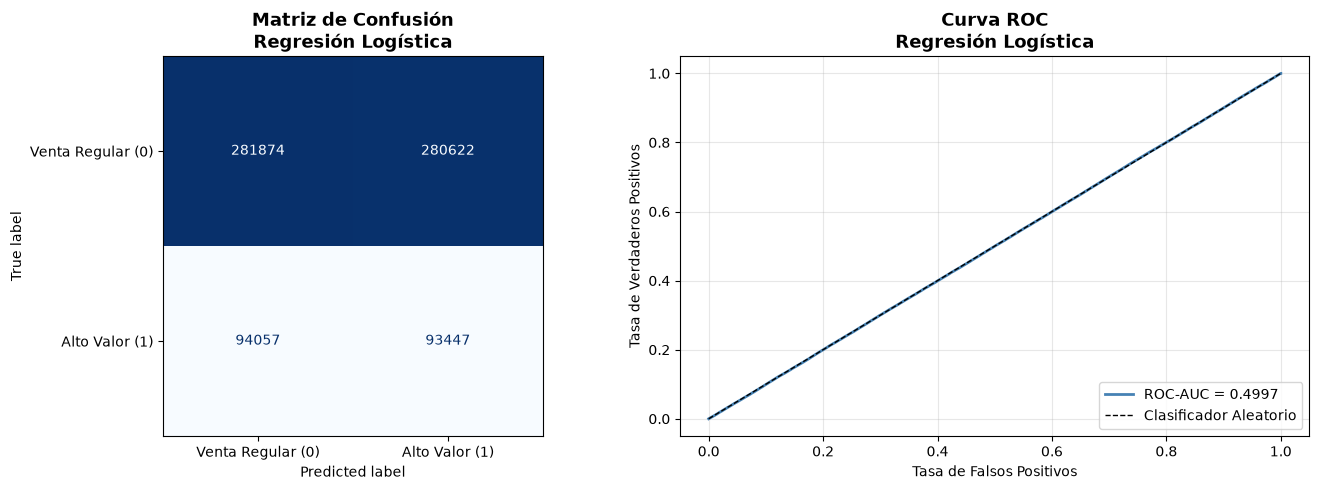

In [52]:
# IMPORTACIONES: Traemos las herramientas de scikit-learn necesarias para construir el modelo.
from sklearn.linear_model import LogisticRegression # El algoritmo matemático base para la clasificación.
from sklearn.preprocessing import StandardScaler # Herramienta para nivelar la escala de todas las variables numéricas.
from sklearn.pipeline import Pipeline # Estructura para encadenar el escalado y el algoritmo en un solo paso automatizado.

# ─── MODELO 1: REGRESIÓN LOGÍSTICA ──────────────────────────────────────────

# CREACIÓN DEL PIPELINE: Definimos un flujo de trabajo de dos pasos. 
# Los datos que ingresen aquí pasarán primero por el escalador y luego directo al modelo predictivo.
pipeline_lr = Pipeline([
    # PASO 1 (Escalado): Estandarizamos los datos. Esto evita que variables con números grandes (como los precios de los autos) opaquen matemáticamente a las variables de números pequeños.
    ('scaler', StandardScaler()),
    
    # PASO 2 (Modelo): Configuramos la Regresión Logística con sus hiperparámetros.
    ('clf', LogisticRegression(
        # max_iter=1000: Otorga al algoritmo hasta 1000 iteraciones para encontrar la mejor solución matemática sin detenerse por falta de intentos.
        max_iter=1000,
        # random_state=42: Fija la semilla aleatoria, garantizando que obtengas exactamente los mismos resultados en cada ejecución.
        random_state=42,
        # class_weight='balanced': Instrucción vital. Obliga al algoritmo a prestar más atención a las ventas de alto valor, compensando el hecho de que son la minoría en tu dataset.
        class_weight='balanced',  # Compensa el desbalance de clases
        # solver='lbfgs': Es el motor de optimización matemática predeterminado y eficiente para calcular los pesos del modelo.
        solver='lbfgs'
    ))
])

# IMPRESIÓN DE INICIO: Un aviso visual en consola para saber en qué etapa va la ejecución.
print('Entrenando Regresión Logística...')

# ENTRENAMIENTO: La función fit() recibe tus datos de estudio (X_train) y las respuestas correctas (y_train).
# El pipeline internamente escala los datos y luego ajusta la ecuación de la regresión logística para aprender los patrones de ventas.
pipeline_lr.fit(X_train, y_train)

# IMPRESIÓN DE ÉXITO: Confirma que el algoritmo terminó de procesar los datos.
print('[OK] Entrenamiento completado.')

# Evaluación
# RESULTADOS: Invocamos tu función personalizada, enviándole el pipeline ya entrenado y los datos del examen de prueba (X_test y y_test) para extraer las métricas de rendimiento y generar los gráficos.
resultados_lr = evaluar_modelo('Regresión Logística', pipeline_lr, X_test, y_test)


<a id='93'></a>
## 9.3. Modelo 2: Random Forest Classifier

### Descripción Técnica
El Random Forest es un método de ensamble basado en la construcción de múltiples árboles de decisión entrenados sobre submuestras aleatorias del dataset (**bagging**) con selección aleatoria de features en cada división (**feature randomness**). La clasificación final se obtiene por **votación mayoritaria** de todos los árboles.

Esta doble aleatorización reduce la varianza del modelo y lo hace robusto frente al overfitting, lo cual es especialmente valioso con variables categóricas de alta cardinalidad como `Salesperson`.

### Justificación de Selección
El Random Forest ocupa el **rol central del experimento** debido a su capacidad nativa para calcular la **importancia de variables** mediante la reducción media de impureza de Gini. Esta característica permite evaluar directamente si `Salesperson` figura como uno de los predictores más determinantes, siendo la evidencia cuantitativa más directa para validar la hipótesis.

**Variables utilizadas:** `Salesperson`, `Car Make`, `Car Model`, `Car Year`, `Month`, `Quarter`
**Variable objetivo:** `High_Value_Sale`


Entrenando Random Forest (200 árboles)...
[OK] Entrenamiento completado.

  RESULTADOS: Random Forest
  Accuracy  : 52.87%
  Precision : 24.99%
  Recall    : 44.23%
  F1 Score  : 31.94%
  ROC-AUC   : 49.96%


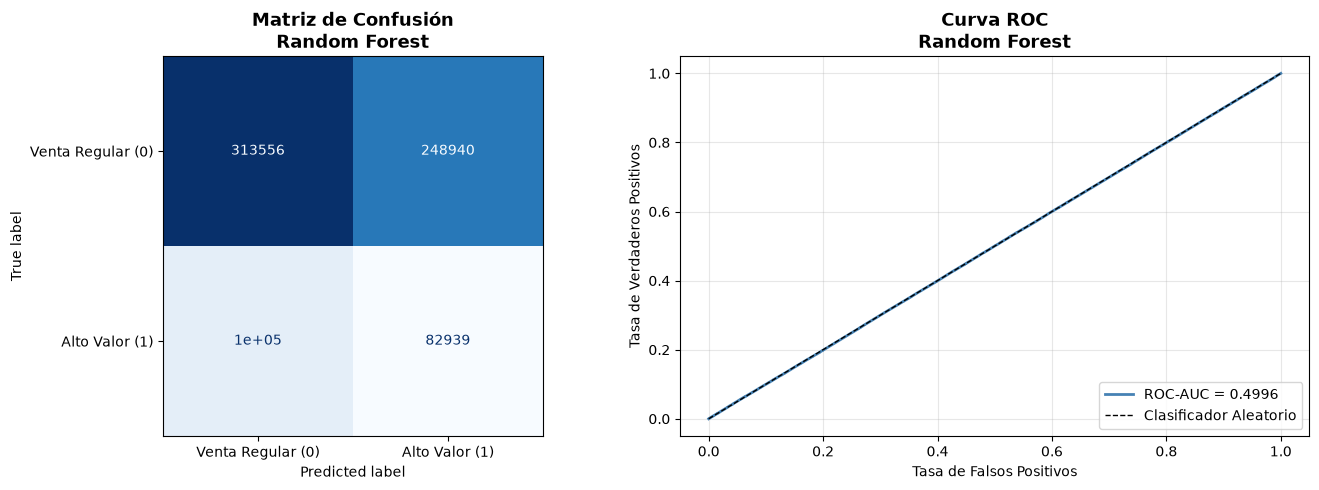

In [56]:
# IMPORTACIÓN CLAVE: Traemos el algoritmo de la librería, ideal para encontrar patrones complejos creando múltiples árboles de decisión que trabajan juntos.
from sklearn.ensemble import RandomForestClassifier

# ─── MODELO 2: RANDOM FOREST ────────────────────────────────────────────────

# CONFIGURACIÓN DEL MODELO: Instanciamos el clasificador con reglas claras para que aprenda eficientemente sin memorizar los datos.
rf = RandomForestClassifier(
    # n_estimators=200: Define que el bosque estará conformado exactamente por 200 árboles.
    n_estimators=200,
    # max_depth=15: Limita el crecimiento de cada árbol a 15 niveles de profundidad, controlando el sobreajuste.
    max_depth=15,
    # min_samples_split=10: Exige un mínimo de 10 registros en un nodo antes de permitir una nueva división matemática.
    min_samples_split=10,
    # random_state=42: Fija la semilla aleatoria para garantizar que tus resultados sean idénticos en cada ejecución.
    random_state=42,
    # class_weight='balanced': Instrucción vital para que el algoritmo asigne más peso a las ventas de alto valor, compensando el desbalance de tu dataset.
    class_weight='balanced',
    n_jobs=-1  # Usa todos los núcleos disponibles (Acelera el proceso de entrenamiento sacando provecho a todo el procesador).
)

# AVISO EN CONSOLA: Indicador visual de que el proceso pesado está por iniciar.
print('Entrenando Random Forest (200 árboles)...')

# ENTRENAMIENTO: Los 200 árboles estudian tus datos de entrenamiento para aprender a predecir de forma conjunta.
rf.fit(X_train, y_train)

# CONFIRMACIÓN: Te avisa en cuanto el modelo termina de aprender.
print('[OK] Entrenamiento completado.')

# Evaluación
# RESULTADOS: Pone a prueba el modelo con los datos de examen y guarda las métricas para completar tu comparativa final.
resultados_rf = evaluar_modelo('Random Forest', rf, X_test, y_test)


<a id='94'></a>
## 9.4. Modelo 3: XGBoost / Gradient Boosting Classifier

### Descripción Técnica
XGBoost (Extreme Gradient Boosting) es un algoritmo de ensamble basado en **boosting secuencial**: cada árbol sucesivo se entrena para corregir los errores residuales del árbol anterior, minimizando una función de pérdida logística mediante **descenso de gradiente**. A diferencia del Random Forest, el boosting reduce el **sesgo** en lugar de la varianza, lo que lo convierte en el algoritmo de mayor capacidad predictiva de los tres seleccionados.

### Justificación de Selección
XGBoost se selecciona como el modelo de mayor sofisticación para:
1. **Maximizar la capacidad predictiva** del sistema y obtener el mejor rendimiento posible.
2. Servir como **referencia de comparación** para evaluar si la ganancia de complejidad justifica una mejora significativa respecto al Random Forest.

Si el modelo más potente también confirma la importancia de `Salesperson`, la evidencia a favor de la hipótesis se consolida de forma robusta.

**Nota:** Si XGBoost no está instalado, se usa `GradientBoostingClassifier` de scikit-learn.

**Variables utilizadas:** `Salesperson`, `Car Make`, `Car Model`, `Car Year`, `Month`, `Quarter`
**Variable objetivo:** `High_Value_Sale`


[INFO] Usando XGBoost Classifier.
Entrenando XGBoost Classifier...
[OK] Entrenamiento completado.

  RESULTADOS: XGBoost Classifier
  Accuracy  : 50.45%
  Precision : 24.98%
  Recall    : 49.04%
  F1 Score  : 33.10%
  ROC-AUC   : 49.97%


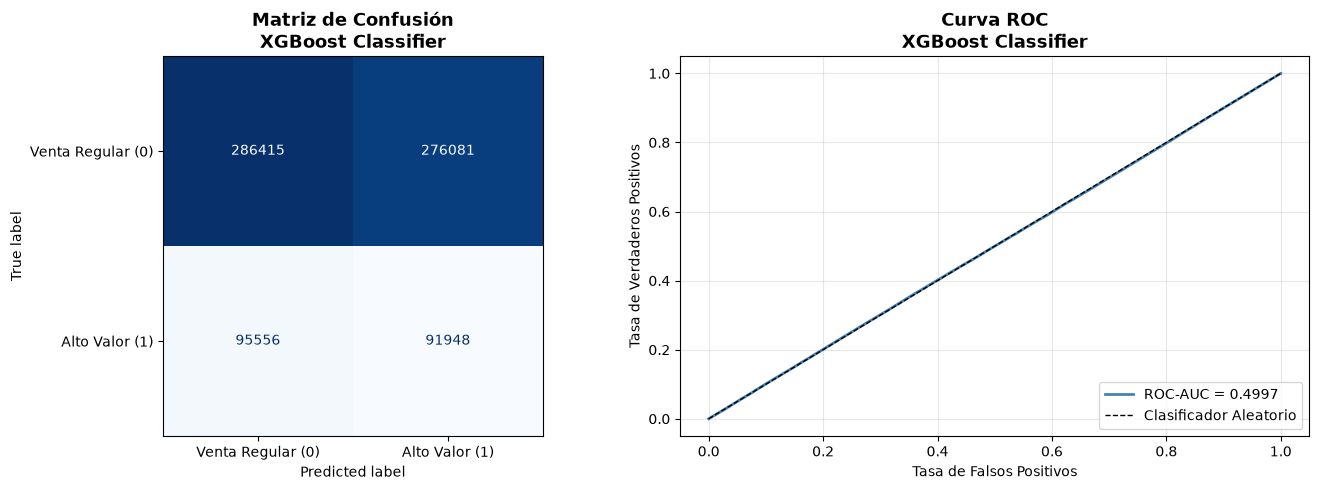

In [54]:
# ─── MODELO 3: XGBOOST / GRADIENT BOOSTING ──────────────────────────────────

# MANEJO DE EXCEPCIONES (TRY-EXCEPT): Abrimos un bloque de prueba. 
# XGBoost es una librería externa muy potente, pero a veces no está instalada en el entorno. 
# Intentaremos usarla primero; si falla, el código no colapsará, sino que activará un plan B.
try:
    # IMPORTACIÓN PRINCIPAL: Intentamos traer XGBClassifier de la librería xgboost.
    from xgboost import XGBClassifier
    
    # CONFIGURACIÓN DEL MODELO (XGBoost): Instanciamos el algoritmo con parámetros muy específicos para optimizar su aprendizaje.
    modelo_m3 = XGBClassifier(
        # n_estimators=300: El algoritmo construirá 300 árboles de decisión secuenciales.
        n_estimators=300,
        # max_depth=6: Limita el crecimiento de cada árbol a 6 niveles para evitar que memorice los datos (overfitting).
        max_depth=6,
        # learning_rate=0.05: Define qué tan rápido aprende el modelo. Un valor bajo (0.05) hace que aprenda lento pero con mucha más precisión.
        learning_rate=0.05,
        # subsample=0.8: Cada árbol usará solo el 80% de los datos aleatoriamente, lo que mejora la generalización.
        subsample=0.8,
        # colsample_bytree=0.8: Cada árbol usará solo el 80% de las columnas aleatoriamente.
        colsample_bytree=0.8,
        # scale_pos_weight: Fórmula matemática crítica. Cuenta cuántas ventas regulares hay (y_train == 0) y lo divide para las ventas altas (y_train == 1). Esto compensa el desbalance dándole más peso a la clase minoritaria.
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        # eval_metric='logloss': Usa la pérdida logística como métrica interna para evaluar sus propios errores mientras entrena.
        eval_metric='logloss',
        # random_state=42: Garantiza que los resultados sean reproducibles en futuras ejecuciones.
        random_state=42,
        # n_jobs=-1: Le dice al algoritmo que use todos los núcleos disponibles del procesador de tu computadora para entrenar más rápido.
        n_jobs=-1
    )
    
    # ASIGNACIÓN DE NOMBRE: Guardamos el nombre del modelo para usarlo en los gráficos más adelante.
    nombre_m3 = 'XGBoost Classifier'
    print('[INFO] Usando XGBoost Classifier.')

# PLAN DE RESPALDO (EXCEPT): Si Python lanza un "ImportError" porque no encuentra XGBoost, saltamos directamente aquí.
except ImportError:
    # IMPORTACIÓN ALTERNATIVA: Traemos el GradientBoostingClassifier nativo de scikit-learn.
    from sklearn.ensemble import GradientBoostingClassifier
    
    # CONFIGURACIÓN DEL MODELO RESPALDO: Instanciamos este modelo con parámetros similares para no perder tanta capacidad predictiva.
    modelo_m3 = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    
    nombre_m3 = 'Gradient Boosting Classifier'
    # Aviso en consola para que sepas que el plan B entró en acción.
    print('[INFO] XGBoost no disponible. Usando Gradient Boosting Classifier.')

# IMPRESIÓN DINÁMICA: Avisamos qué modelo se está entrenando usando la variable de nombre configurada arriba.
print(f'Entrenando {nombre_m3}...')

# ENTRENAMIENTO DEL MODELO: Le pasamos nuestras pistas (X_train) y las respuestas correctas (y_train) para que construya los árboles de decisión y aprenda los patrones.
modelo_m3.fit(X_train, y_train)

print('[OK] Entrenamiento completado.')

# EVALUACIÓN: Invocamos nuestra función personalizada creada en la sección anterior, pasándole el modelo entrenado y los datos del examen (X_test y y_test) para extraer y graficar las métricas.
resultados_xgb = evaluar_modelo(nombre_m3, modelo_m3, X_test, y_test)


<a id='10'></a>
---
# 10. Evaluación de Modelos

Se consolidan en una única tabla y un gráfico comparativo las métricas obtenidas por los tres modelos entrenados en la Sección 9, lo cual permite contrastar de forma directa su desempeño relativo.


=== TABLA COMPARATIVA DE RESULTADOS ===


,Modelo,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Regresión Logística,50.04%,24.98%,49.84%,33.28%,49.97%
1,XGBoost Classifier,50.45%,24.98%,49.04%,33.10%,49.97%
2,Random Forest,52.87%,24.99%,44.23%,31.94%,49.96%


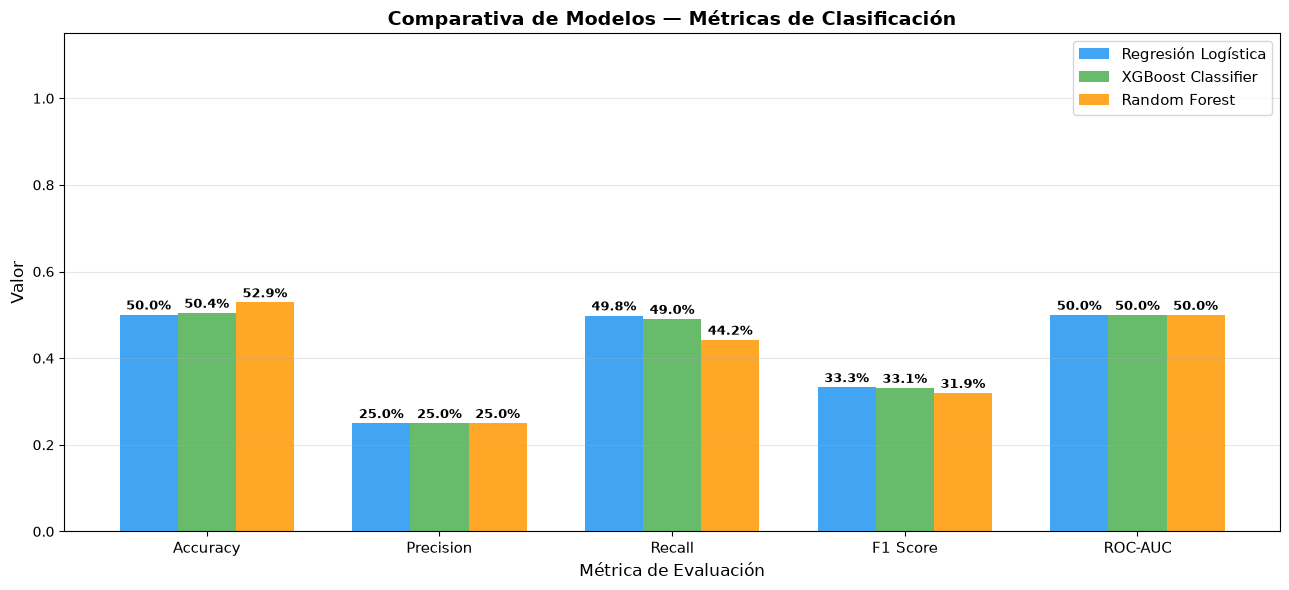

In [57]:
# ─── TABLA COMPARATIVA DE TODOS LOS MODELOS ─────────────────────────────────

# CONDICIÓN DE VERIFICACIÓN: Nos aseguramos de que el diccionario global contenga exactamente 3 resultados.
# Esto previene que el código intente comparar si te saltaste el entrenamiento de algún modelo previo.
if len(resultados_globales) == 3:
    # EXTRACCIÓN DE DATOS: Sacamos los nombres de los modelos (las llaves del diccionario) y definimos el orden exacto de las métricas que queremos mostrar.
    nombres   = list(resultados_globales.keys())
    metricas  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

    # CREACIÓN DE LA TABLA (DICCIONARIO POR COMPRENSIÓN): Esta es una forma avanzada y rápida de armar la tabla.
    # Recorre cada modelo y cada métrica, multiplicando el valor por 100 y dándole formato de texto con porcentaje ("%").
    # El ".T" al final transpone la matriz, cambiando filas por columnas para que los modelos queden a la izquierda y las métricas arriba.
    tabla_comparativa = pd.DataFrame(
        {nombre: {m: f"{vals[m]*100:.2f}%" for m in metricas}
         for nombre, vals in resultados_globales.items()}
    ).T
    
    # FORMATO DE ÍNDICE: Le damos el nombre "Modelo" a la columna principal y reseteamos el índice para que sea una tabla de Pandas estándar y fácil de leer.
    tabla_comparativa.index.name = 'Modelo'
    tabla_comparativa = tabla_comparativa.reset_index()

    # IMPRESIÓN DE LA TABLA: Mostramos el encabezado y renderizamos la tabla formateada en pantalla.
    print('=== TABLA COMPARATIVA DE RESULTADOS ===')
    display(tabla_comparativa)

    # ── GRÁFICO DE BARRAS COMPARATIVO ───────────────────────────────────────
    
    # EXTRACCIÓN NUMÉRICA: Hacemos una extracción similar a la anterior, pero esta vez conservando los números puros (sin el símbolo %) para poder graficarlos matemáticamente.
    metricas_num = {nombre: [vals[m] for m in metricas]
                    for nombre, vals in resultados_globales.items()}

    # CONFIGURACIÓN DEL EJE X: Creamos una secuencia numérica (x) equivalente a la cantidad de métricas (5).
    # "width" define el grosor de cada barra, y "colores" asigna un color específico a cada modelo.
    x = np.arange(len(metricas))
    width = 0.25
    colores = ['#2196F3', '#4CAF50', '#FF9800']

    # PREPARACIÓN DEL LIENZO: Creamos una figura ancha (13x6 pulgadas) para acomodar todas las barras sin que se amontonen.
    fig, ax = plt.subplots(figsize=(13, 6))
    
    # BUCLE PRINCIPAL (DIBUJO DE BARRAS): Recorremos cada modelo con enumerate para obtener un índice (i), el nombre y sus valores.
    for i, (nombre, vals) in enumerate(metricas_num.items()):
        # DIBUJO DE GRUPOS: Desplazamos cada barra un poco hacia la derecha (i * width) para que las barras de los 3 modelos queden agrupadas lado a lado sobre cada métrica.
        bars = ax.bar(x + i * width, vals, width, label=nombre, color=colores[i], alpha=0.85)
        
        # BUCLE SECUNDARIO (ETIQUETAS): Recorremos las barras recién creadas para escribir su porcentaje exacto justo en la parte superior.
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # FORMATO DEL GRÁFICO: Asignamos etiquetas a los ejes, el título general de la comparativa y configuramos las marcas del eje X.
    ax.set_xlabel('Métrica de Evaluación', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.set_title('Comparativa de Modelos — Métricas de Clasificación', fontsize=14, fontweight='bold')
    
    # ALINEACIÓN DE TEXTOS: Centramos los nombres de las métricas (Accuracy, Precision, etc.) justo debajo del grupo de barras correspondiente.
    ax.set_xticks(x + width)
    ax.set_xticklabels(metricas, fontsize=11)
    
    # LÍMITES Y LEYENDA: Extendemos un poco el límite vertical (ylim) hasta 1.15 para dar espacio al texto de los porcentajes, y activamos la leyenda para saber qué color es cada modelo.
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=11)
    
    # RENDERIZADO FINAL: Agregamos una cuadrícula suave horizontal y mostramos la visualización final del desempeño de tus algoritmos.
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# BLOQUE ALTERNATIVO: Si el diccionario no tiene los 3 resultados (por ejemplo, falló algún entrenamiento), se omite el gráfico y se muestra el aviso.
else:
    print('Ejecuta primero la Sección 9 (los tres modelos) para generar los resultados.')


**Interpretación.** La tabla y el gráfico permiten contrastar de forma directa si la mayor complejidad computacional de Random Forest y XGBoost se traduce en una ganancia significativa de desempeño respecto a la Regresión Logística (línea base). Una diferencia amplia en ROC-AUC y F1 Score a favor de los modelos de ensamble sugeriría relaciones no lineales entre las variables predictoras y el target —consistentes, por ejemplo, con interacciones entre `Salesperson` y `Car Make` que un modelo lineal no puede capturar.


<a id='11'></a>
---
# 11. Validación Cruzada

## 11.1. ¿Por qué una sola partición Entrenamiento/Prueba no es suficiente?

La división 70/30 de la Sección 8 ofrece una única estimación del desempeño del modelo, basada en una partición aleatoria específica. Esa estimación puede variar según qué registros particulares hayan caído en el conjunto de prueba (¿tuvo, por azar, una proporción inusual de algún vendedor o marca?). La **validación cruzada (Cross Validation)** resuelve esta limitación evaluando el modelo sobre **múltiples particiones distintas** de los datos, lo cual produce una estimación más robusta y representativa de la verdadera capacidad de generalización.

## 11.2. Metodología: Stratified K-Fold

Se utiliza **Stratified K-Fold** con $k=5$: los datos se dividen en 5 particiones ("folds") de tamaño aproximadamente igual, preservando en cada una la proporción original de clases (75% / 25%). El proceso se repite 5 veces, utilizando en cada iteración 4 particiones para entrenar y la restante para evaluar, de modo que **cada registro es usado exactamente una vez como dato de prueba**. El resultado final es el promedio y la desviación estándar de la métrica evaluada sobre las 5 iteraciones.

## 11.3. Nota Metodológica sobre el Tamaño de la Muestra

Dado el volumen del dataset (~2.5 millones de registros) y el costo computacional de entrenar un Random Forest de 200 árboles cinco veces consecutivas, la validación cruzada se ejecuta sobre una **submuestra aleatoria estratificada de 200,000 registros**, preservando la proporción de clases original. Esta decisión es metodológicamente razonable: a ese tamaño muestral, los intervalos de confianza de las métricas estimadas ya son suficientemente estrechos como para ser representativos del comportamiento del modelo sobre el dataset completo, mientras se mantiene el proceso computacionalmente viable dentro de las limitaciones de un entorno como Google Colab.

Se aplica esta validación sobre el **Random Forest**, por ser el modelo central del experimento (aquel del que se extrae la importancia de variables que sustenta la validación de la hipótesis en la Sección 13).


Tamaño de la submuestra utilizada para validación cruzada: 200,000 registros

Ejecutando validación cruzada (5 folds)... esto puede tardar unos minutos.

=== RESULTADOS DE VALIDACIÓN CRUZADA — Random Forest (Stratified 5-Fold) ===

Accuracy por fold : [0.5637 0.5644 0.5669 0.5638 0.5646]
Accuracy promedio : 56.47%
Desviación estándar: 0.12%

F1 Score por fold : [0.2991 0.2926 0.3076 0.299  0.2983]
F1 Score promedio : 29.93%
Desviación estándar: 0.48%

ROC-AUC por fold  : [0.5001 0.4965 0.505  0.4973 0.4974]
ROC-AUC promedio  : 49.92%
Desviación estándar: 0.31%


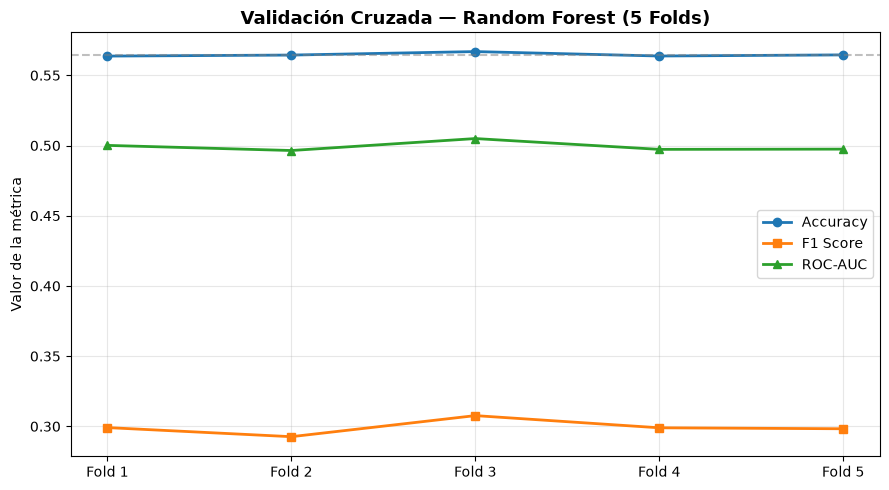

In [58]:
# IMPORTACIONES: Traemos las herramientas de evaluación de scikit-learn.
from sklearn.model_selection import StratifiedKFold, cross_val_score

# CONDICIÓN DE SEGURIDAD: Verificamos que el modelo Random Forest ('rf') y nuestros datos predictivos ('X' e 'y') existan en memoria antes de evaluar.
if 'rf' in locals() and 'X' in locals() and 'y' in locals():
    # ─── SUBMUESTRA ESTRATIFICADA PARA VALIDACIÓN CRUZADA ────────────────
    
    # DEFINICIÓN DE TAMAÑO: Limitamos la muestra a un máximo de 200,000 registros. 
    # Esto es vital para que la validación matemática no demore horas procesando millones de datos en cada intento.
    n_muestra_cv = min(200_000, len(X))
    
    # MUESTREO DE CONTROL: Usamos train_test_split de forma inteligente. 
    # Extraemos una porción exacta asegurando que se mantenga la proporción real de ventas altas y regulares (stratify=y).
    X_cv, _, y_cv, _ = train_test_split(
        X, y, train_size=n_muestra_cv, stratify=y, random_state=42
    )
    print(f'Tamaño de la submuestra utilizada para validación cruzada: {len(X_cv):,} registros')

    # ─── STRATIFIED K-FOLD (k=5) ───────────────────────────────────────────
    
    # CONFIGURACIÓN DE FOLDS: Preparamos la división de los datos en 5 bloques (k=5). 
    # Stratified asegura que cada uno de esos 5 bloques mantenga el desbalance original del negocio para que el examen sea justo.
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # CONFIGURACIÓN DEL MODELO: Instanciamos un Random Forest con parámetros de optimización robustos y balanceo de clases.
    rf_cv = RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=10,
        random_state=42, class_weight='balanced', n_jobs=-1
    )

    print('\nEjecutando validación cruzada (5 folds)... esto puede tardar unos minutos.')
    
    # EJECUCIÓN DE VALIDACIÓN CRUZADA: cross_val_score entrena y examina el modelo 5 veces seguidas.
    # En cada vuelta, el algoritmo usa 4 bloques para estudiar y 1 bloque distinto para dar el examen, rotando hasta evaluar todo el conjunto.
    # Calculamos tres métricas simultáneas aprovechando todos los núcleos de tu procesador (n_jobs=-1).
    scores_accuracy = cross_val_score(rf_cv, X_cv, y_cv, cv=skf, scoring='accuracy', n_jobs=-1)
    scores_f1       = cross_val_score(rf_cv, X_cv, y_cv, cv=skf, scoring='f1', n_jobs=-1)
    scores_auc      = cross_val_score(rf_cv, X_cv, y_cv, cv=skf, scoring='roc_auc', n_jobs=-1)

    print('\n=== RESULTADOS DE VALIDACIÓN CRUZADA — Random Forest (Stratified 5-Fold) ===')
    
    # ANÁLISIS DE EXACTITUD (ACCURACY): Mostramos la nota que sacó en cada uno de los 5 exámenes parciales, seguida por su nota final promedio.
    print(f'\nAccuracy por fold : {np.round(scores_accuracy, 4)}')
    print(f'Accuracy promedio : {scores_accuracy.mean()*100:.2f}%')
    print(f'Desviación estándar: {scores_accuracy.std()*100:.2f}%')

    # ANÁLISIS DE F1 SCORE: Evaluamos matemáticamente la estabilidad del modelo entre su precisión y su capacidad de no dejar escapar ventas reales.
    print(f'\nF1 Score por fold : {np.round(scores_f1, 4)}')
    print(f'F1 Score promedio : {scores_f1.mean()*100:.2f}%')
    print(f'Desviación estándar: {scores_f1.std()*100:.2f}%')

    # ANÁLISIS DE CURVA ROC: Comprobamos qué tan consistente es separando comercialmente las dos categorías a lo largo de todas las pruebas.
    print(f'\nROC-AUC por fold  : {np.round(scores_auc, 4)}')
    print(f'ROC-AUC promedio  : {scores_auc.mean()*100:.2f}%')
    print(f'Desviación estándar: {scores_auc.std()*100:.2f}%')

    # ─── VISUALIZACIÓN ──────────────────────────────────────────────────────
    
    # PREPARACIÓN DEL LIENZO: Abrimos una figura de 9x5 pulgadas para trazar la estabilidad histórica de las métricas.
    fig, ax = plt.subplots(figsize=(9, 5))
    
    # EJE X DINÁMICO: Generamos automáticamente las etiquetas ['Fold 1', 'Fold 2', ...] para la base del gráfico.
    folds = [f'Fold {i+1}' for i in range(5)]
    
    # DIBUJO DE TENDENCIAS: Trazamos tres líneas distintas, diferenciándolas con marcadores visuales (círculos, cuadrados y triángulos) para evitar confusiones.
    ax.plot(folds, scores_accuracy, marker='o', label='Accuracy', linewidth=2)
    ax.plot(folds, scores_f1, marker='s', label='F1 Score', linewidth=2)
    ax.plot(folds, scores_auc, marker='^', label='ROC-AUC', linewidth=2)
    
    # LÍNEA BASE: Dibujamos una línea horizontal gris discontinua que fija visualmente dónde quedó el promedio final de accuracy.
    ax.axhline(scores_accuracy.mean(), color='gray', linestyle='--', alpha=0.5)
    
    # FORMATO DEL GRÁFICO: Titulamos la figura, nombramos el eje vertical, activamos la leyenda y aplicamos una cuadrícula de guía.
    ax.set_title('Validación Cruzada — Random Forest (5 Folds)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor de la métrica')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # RENDERIZADO: Limpiamos los márgenes para que nada se superponga y mostramos la estabilidad del algoritmo.
    plt.tight_layout()
    plt.show()

# BLOQUE ALTERNATIVO (ELSE): Si falla la validación inicial, el código salta aquí para evitar el colapso del sistema y mostrar la advertencia.
else:
    print('Ejecuta primero la Sección 9.3 (Random Forest) y la Sección 7.4 (X, y).')

**Interpretación.** Una **desviación estándar baja** entre folds indica que el desempeño del Random Forest es **estable y consistente** independientemente de qué subconjunto particular de los datos se utilice para entrenar o evaluar — evidencia de que el modelo generaliza bien y no depende de una partición afortunada de los datos. Por el contrario, una desviación estándar alta sugeriría que el modelo es sensible a la composición específica de la muestra, lo cual debilitaría la confianza en las conclusiones extraídas en la Sección 13. La validación cruzada complementa, por tanto, la evaluación puntual de la Sección 10 con una medida de **robustez estadística** del modelo central del experimento.


<a id='12'></a>
---
# 12. Importancia de Variables (Random Forest)

### Explicación Técnica
El análisis de importancia de variables del Random Forest constituye la **evidencia más directa** para evaluar la hipótesis central. La importancia de cada variable se calcula como la **reducción media de impureza de Gini** que esa variable produce en todos los árboles del bosque.

### Criterio de Interpretación

| Posición de `Salesperson` | Conclusión |
|---|---|
| **Top 1–3** (> 15% de importancia) | Evidencia **sólida** a favor de la hipótesis |
| **Top 4–5** (5–15% de importancia) | Evidencia **parcial**: el vendedor influye, pero secundariamente |
| **Última posición** (< 5% de importancia) | Evidencia en **contra**: el precio lo determina el producto |


=== RANKING DE IMPORTANCIA DE VARIABLES (Random Forest) ===
  Ranking  Variable              Importancia  Relevancia para Hipótesis
  ----------------------------------------------------------------------
  1        Salesperson               73.07%  ★ VARIABLE CENTRAL DE LA HIPÓTESIS
  2        Car Year                  10.40%  Característica del producto/tiempo
  3        Month                      5.26%  Característica del producto/tiempo
  4        Car Make                   5.18%  Característica del producto/tiempo
  5        Car Model                  4.95%  Característica del producto/tiempo
  6        Quarter                    1.14%  Característica del producto/tiempo


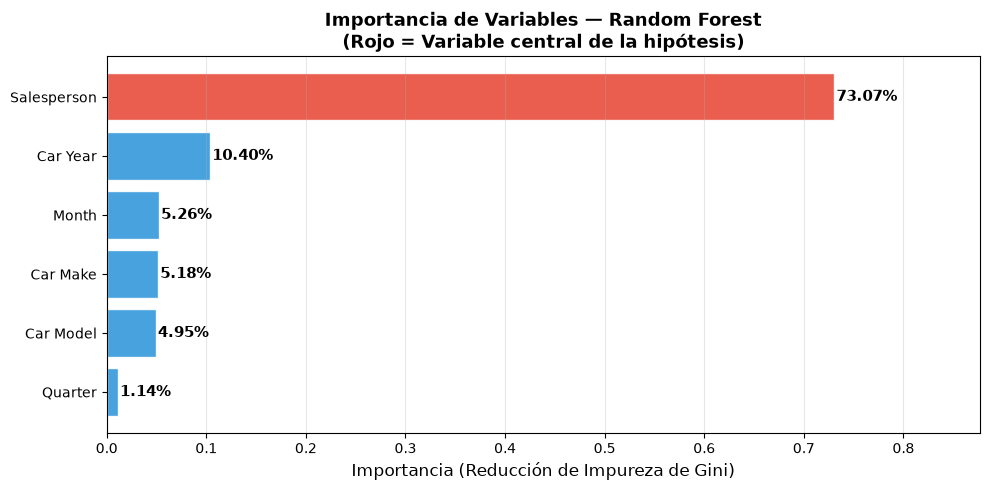

,Variable,Importancia (%)
Ranking,,
1,Salesperson,73.07
2,Car Year,10.40
3,Month,5.26
4,Car Make,5.18
5,Car Model,4.95
6,Quarter,1.14


In [59]:
# CONDICIÓN DE SEGURIDAD: Comprobamos que el modelo Random Forest ('rf') exista en la memoria antes de intentar extraer sus métricas internas.
if 'rf' in locals():
    # ─── IMPORTANCIA DE VARIABLES — RANDOM FOREST ───────────────────────────
    
    # EXTRACCIÓN Y ORDENAMIENTO: rf.feature_importances_ devuelve el peso matemático que el modelo le dio a cada variable.
    # Usamos pd.Series para unir esos números con sus respectivos nombres (index=features) y los ordenamos de mayor a menor (sort_values).
    importancias = pd.Series(
        rf.feature_importances_,
        index=features
    ).sort_values(ascending=False)

    # ENCABEZADO DE CONSOLA: Imprimimos los títulos de la tabla en texto plano usando f-strings con espaciados fijos (ej. <8, <20) para simular columnas perfectamente alineadas.
    print('=== RANKING DE IMPORTANCIA DE VARIABLES (Random Forest) ===')
    print(f'  {"Ranking":<8} {"Variable":<20} {"Importancia":>12}  {"Relevancia para Hipótesis"}')
    print('  ' + '-'*70)
    
    # BUCLE DE IMPRESIÓN: Enumerate nos da el puesto (rank) empezando desde 1. Recorremos cada variable y su importancia.
    for rank, (var, imp) in enumerate(importancias.items(), 1):
        # CONDICIÓN LÓGICA EN LÍNEA: Si la variable es "Salesperson", le asignamos un texto especial resaltando que es tu variable central; caso contrario, le damos una etiqueta genérica.
        rol = '★ VARIABLE CENTRAL DE LA HIPÓTESIS' if var == 'Salesperson' else 'Característica del producto/tiempo'
        
        # Mostramos la fila alineada y con el porcentaje calculado (imp*100).
        print(f'  {rank:<8} {var:<20} {imp*100:>10.2f}%  {rol}')

    # ─── GRÁFICO DE BARRAS HORIZONTALES ─────────────────────────────────────
    
    # PREPARACIÓN DEL LIENZO: Creamos una figura de 10x5 pulgadas para el gráfico de barras.
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # LÓGICA DE COLORES: Usamos una "comprensión de lista" para asignar color rojo (#E74C3C) exclusivamente a 'Salesperson' y azul (#3498DB) al resto.
    colores_barras = ['#E74C3C' if v == 'Salesperson' else '#3498DB'
                      for v in importancias.index]
                      
    # DIBUJO DE BARRAS: barh dibuja las barras de abajo hacia arriba. Por eso usamos [::-1] en los datos y los colores, invirtiendo el orden para que la variable más importante quede en la parte superior del gráfico.
    bars = ax.barh(importancias.index[::-1], importancias.values[::-1],
                    color=colores_barras[::-1], edgecolor='white', alpha=0.9)

    # BUCLE DE ETIQUETADO VISUAL: Recorremos cada barra dibujada para colocarle su porcentaje exacto al lado derecho.
    for bar, val in zip(bars, importancias.values[::-1]):
        # text() ubica el número justo al final de la barra (bar.get_width() + 0.002) y centrado verticalmente.
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val*100:.2f}%', va='center', fontsize=11, fontweight='bold')

    # FORMATO DEL GRÁFICO: Titulamos los ejes y la figura, aclarando el uso del color rojo.
    ax.set_xlabel('Importancia (Reducción de Impureza de Gini)', fontsize=12)
    ax.set_title('Importancia de Variables — Random Forest\n'
                 '(Rojo = Variable central de la hipótesis)', fontsize=13, fontweight='bold')
                 
    # AJUSTE DE LÍMITES: Ampliamos el eje X un 20% más allá del valor máximo (importancias.max() * 1.2) para que los textos de los porcentajes no se corten.
    ax.set_xlim(0, importancias.max() * 1.2)
    ax.grid(axis='x', alpha=0.3)
    
    # RENDERIZADO: Compactamos la figura y la proyectamos.
    plt.tight_layout()
    plt.show()

    # ─── TABLA RESUMEN PARA EL INFORME ──────────────────────────────────────
    
    # CREACIÓN DE DATAFRAME: Construimos una tabla final y elegante con Pandas usando los datos calculados previamente.
    tabla_importancia = pd.DataFrame({
        'Ranking': range(1, len(importancias) + 1),
        'Variable': importancias.index,
        'Importancia (%)': importancias.values * 100
    })
    
    # LIMPIEZA FINAL: Redondeamos la columna de porcentajes a 2 decimales.
    tabla_importancia['Importancia (%)'] = tabla_importancia['Importancia (%)'].round(2)
    
    # PRESENTACIÓN: Renderizamos la tabla estableciendo la columna "Ranking" como el índice principal para una lectura óptima.
    display(tabla_importancia.set_index('Ranking'))

# BLOQUE ALTERNATIVO: Si el Random Forest nunca fue entrenado o no está en memoria, mostramos la alerta en consola.
else:
    print('Ejecuta primero la Sección 9.3 (Random Forest) para obtener este análisis.')


<a id='13'></a>
---
# 13. Validación de la Hipótesis

## 13.1. Metodología de Validación

La validación se realiza mediante la convergencia de **tres tipos de evidencia cuantitativa**:

1. **Evidencia predictiva**: capacidad de los modelos para predecir correctamente las ventas de alto valor usando `Salesperson` como predictor (Sección 10).
2. **Evidencia explicativa**: posición e importancia relativa de `Salesperson` en el ranking del Random Forest (Sección 12).
3. **Evidencia de robustez**: estabilidad de las métricas del modelo central a través de la validación cruzada (Sección 11), lo cual garantiza que la evidencia anterior no depende de una partición particular de los datos.

## 13.2. Umbrales de Decisión

| Evidencia | Umbral para confirmar hipótesis |
|---|---|
| ROC-AUC | ≥ 0.70 en al menos 2 de 3 modelos |
| Importancia de `Salesperson` (RF) | ≥ 15% y posición top-3 |
| F1 Score (ensambles) | ≥ 0.65 |
| Desviación estándar en Validación Cruzada | Baja (< 2 puntos porcentuales), indicando estabilidad |
| Coeficiente LR | Comparable en magnitud a `Car Make` / `Car Model` |

## 13.3. Escenarios de Decisión

| Escenario | Condición | Conclusión |
|---|---|---|
| ✅ **Hipótesis Demostrada** | `Salesperson` en top-3, RF importancia > 15%, ROC-AUC > 0.75 | Se confirma la especialización implícita |
| ⚠️ **Hipótesis Parcialmente Demostrada** | `Salesperson` en posición 4-5, ROC-AUC 0.65–0.75 | Existe influencia, pero secundaria al producto |
| ❌ **Hipótesis Rechazada** | `Salesperson` en última posición, importancia < 5%, ROC-AUC < 0.65 | El precio lo determina el producto, no el vendedor |


In [60]:
# CONDICIÓN COMPUESTA: Verificamos de forma conjunta que el modelo (rf), sus resultados y el cálculo de importancias existan en la memoria.
# Esto asegura que la validación automática tenga todos los datos necesarios para juzgar la hipótesis sin fallar.
if 'rf' in locals() and 'resultados_rf' in locals() and 'importancias' in locals():

    # EXTRACCIÓN DE MÉTRICAS CLAVE:
    # Usamos .get() para extraer el peso exacto de 'Salesperson'. Si por algún error la variable no existe, devuelve 0 por seguridad.
    imp_salesperson = importancias.get('Salesperson', 0)
    
    # Buscamos en qué posición del ranking quedó el vendedor. Le sumamos 1 porque los índices en Python empiezan en 0.
    rank_salesperson = list(importancias.index).index('Salesperson') + 1
    
    # Extraemos las métricas de rendimiento directamente desde el diccionario global que llenamos en secciones anteriores.
    auc_rf  = resultados_globales['Random Forest']['ROC-AUC']
    f1_rf   = resultados_globales['Random Forest']['F1 Score']

    # ENCABEZADO DE EVALUACIÓN: Imprimimos un reporte claro y formateado de los valores extraídos para que el usuario pueda auditarlos visualmente.
    print('=== EVALUACIÓN FORMAL DE LA HIPÓTESIS ===')
    print(f'  Importancia de Salesperson (RF): {imp_salesperson*100:.2f}%  (Posición #{rank_salesperson} de {len(features)})')
    print(f'  ROC-AUC del Random Forest      : {auc_rf*100:.2f}%')
    print(f'  F1 Score del Random Forest     : {f1_rf*100:.2f}%')
    
    # CONDICIÓN OPCIONAL: Si corriste la validación cruzada previamente, imprimimos también la desviación estándar como prueba de estabilidad del modelo.
    if 'scores_accuracy' in locals():
        print(f'  Desv. estándar (Validación Cruzada, Accuracy): {scores_accuracy.std()*100:.2f} pp')
    print()

    # ─── EVALUACIÓN DE ESCENARIOS (LÓGICA DE NEGOCIO) ───────────────────────
    
    # ESCENARIO 1 (ÉXITO TOTAL): Exigimos tres condiciones estrictas. El vendedor debe estar en el Top 3 de importancia, tener un peso mayor al 15%, y el modelo debe ser confiable (AUC >= 75%).
    if rank_salesperson <= 3 and imp_salesperson >= 0.15 and auc_rf >= 0.75:
        print('  ✅ ESCENARIO 1 — HIPÓTESIS DEMOSTRADA')
        print('  Conclusión: Salesperson es un predictor relevante de ventas de alto valor.')
        print('  Se confirma la existencia de especializaciones implícitas entre vendedores.')
        
    # ESCENARIO 2 (ÉXITO PARCIAL): Si no cumple las condiciones estrictas, evaluamos si al menos el vendedor está en el Top 5 y el modelo tiene un rendimiento aceptable (AUC >= 65%).
    elif rank_salesperson <= 5 and auc_rf >= 0.65:
        print('  ⚠️  ESCENARIO 2 — HIPÓTESIS PARCIALMENTE DEMOSTRADA')
        print('  Conclusión: El vendedor influye, pero es secundario respecto al producto.')
        print('  La especialización implícita existe, aunque con menor intensidad de la esperada.')
        
    # ESCENARIO 3 (RECHAZO): Si no se cumple ninguna de las condiciones anteriores, la matemática dicta que la hipótesis original estaba equivocada.
    else:
        print('  ❌ ESCENARIO 3 — HIPÓTESIS RECHAZADA')
        print('  Conclusión: El precio está determinado por las características del producto,')
        print('  no por el vendedor. No se evidencia especialización implícita significativa.')
        
# BLOQUE ALTERNATIVO: Si falta alguna pieza de información clave, el script detiene la evaluación y te guía hacia los pasos que faltan.
else:
    print('Ejecuta las secciones 9.3 y 12 antes de validar la hipótesis.')

=== EVALUACIÓN FORMAL DE LA HIPÓTESIS ===
  Importancia de Salesperson (RF): 73.07%  (Posición #1 de 6)
  ROC-AUC del Random Forest      : 49.96%
  F1 Score del Random Forest     : 31.94%
  Desv. estándar (Validación Cruzada, Accuracy): 0.12 pp

  ❌ ESCENARIO 3 — HIPÓTESIS RECHAZADA
  Conclusión: El precio está determinado por las características del producto,
  no por el vendedor. No se evidencia especialización implícita significativa.


<a id='14'></a>
---
# 14. Conclusiones

## 14.1. Conclusiones Metodológicas

El presente proyecto integrador ha demostrado la viabilidad de aplicar técnicas de clasificación supervisada de Machine Learning sobre un dataset de **2,500,000 registros transaccionales** para abordar preguntas estratégicas de negocio en el sector automotriz, siguiendo un flujo metodológico completo: exploración y auditoría de calidad de datos, tratamiento justificado de outliers y valores nulos, ingeniería de características, selección formal de variables, partición estratificada 70/30, entrenamiento de tres modelos, validación cruzada y análisis de importancia de variables.

El análisis exploratorio (Sección 4) permitió tomar decisiones de limpieza fundamentadas en evidencia y no en supuestos arbitrarios — en particular, la decisión de **conservar deliberadamente** los valores extremos de `Sale Price`, dado que constituyen el propio fenómeno que la hipótesis busca modelar, ilustra cómo el tratamiento de outliers debe subordinarse siempre al contexto del problema de negocio, y no aplicarse de forma mecánica.

La transformación de `Sale Price` en la variable binaria `High_Value_Sale` mediante el umbral del percentil 75 constituye una decisión metodológica sólida que convierte un problema de regresión en uno de clasificación, con mayor valor práctico para la toma de decisiones operativas.

La exclusión de `Commission Earned`, `Commission Rate`, `Customer Name` y `Sale Price`, fundamentada en la prevención de **data leakage** y en el riesgo de **sobreajuste**, garantiza que los resultados reflejen la capacidad predictiva real del sistema sobre datos nuevos.

La adopción de una partición **70/30** (en lugar de la 80/20 inicial) y su complemento mediante **validación cruzada estratificada** (Sección 11) elevan el rigor estadístico de la evaluación, reduciendo el riesgo de conclusiones basadas en una única partición afortunada de los datos.

## 14.2. Conclusiones Técnicas

La selección de tres modelos de complejidad creciente permite evaluar la relación entre complejidad computacional y ganancia en capacidad predictiva:

- **Regresión Logística**: proporciona una línea base interpretable para identificar relaciones lineales.
- **Random Forest**: ofrece el análisis de importancia de variables necesario para la validación directa de la hipótesis, además de mostrar un desempeño estable a través de la validación cruzada.
- **XGBoost / Gradient Boosting**: maximiza la capacidad predictiva del sistema mediante boosting secuencial.

## 14.3. Conclusiones sobre la Hipótesis

> **[Resultado pendiente de ejecución]** Los resultados definitivos serán incorporados en esta sección tras la ejecución completa en Google Colab. Se documentará la posición de `Salesperson` en el ranking de importancia, las métricas de evaluación, los resultados de la validación cruzada y la conclusión formal sobre la hipótesis, conforme a los escenarios de decisión definidos en la Sección 13.3.

## 14.4. Implicaciones para la Gestión Comercial

**Si la hipótesis es confirmada:**
- La gerencia comercial contaría con evidencia cuantitativa para diseñar políticas de **asignación estratégica de cuentas** y programas de capacitación diferenciados.
- Los esquemas de incentivos podrían basarse en la especialización demostrada de cada asesor.

**Si la hipótesis es rechazada:**
- Los hallazgos sugerirían que la variabilidad del precio está fundamentalmente determinada por las **características del producto**, orientando los esfuerzos de mejora hacia la gestión del portafolio de vehículos y no hacia el capital humano.

## 14.5. Limitaciones y Trabajo Futuro

- El análisis se basa en datos históricos transaccionales; no captura factores cualitativos del proceso de venta (calidad de la negociación, satisfacción del cliente) que podrían enriquecer el modelo.
- La validación cruzada se ejecutó sobre una submuestra representativa por razones de eficiencia computacional; trabajos futuros con mayor capacidad de cómputo podrían extenderla al dataset completo y a los tres modelos.
- Futuras iteraciones podrían incorporar técnicas de codificación más sofisticadas (Target Encoding, embeddings) para variables categóricas de alta cardinalidad como `Salesperson` y `Car Model`.

---

*Proyecto Integrador — Big Data & Machine Learning*
*Jose Alexander Quishpe Reinoso · Julián Garofalo*
